<div style="background-color:#234c7d; border-radius:8px; padding:32px 40px 24px; margin-bottom:8px;">
  <h1 style="margin:0 0 6px; font-size:28px; font-weight:600; color:#C49A28; letter-spacing:-0.5px;">
    GA Image Approximation
  </h1>
  <p style="margin:0; font-size:13px; color:#a8b8d0; letter-spacing:0.5px;">
    Implementation & Analysis Notebook
  </p>
</div>

<div style="border:1.5px solid #234c7d; border-radius:8px; padding:20px 40px; margin-bottom:8px; display:flex; gap:48px;">
  <div>
    <p style="margin:0 0 8px; font-size:11px; font-weight:600; color:#888; letter-spacing:1px; text-transform:uppercase;">Group 35 - Convergence</p>
    <p style="margin:0; font-size:14px; color:#2d2d2d; line-height:2;">
      Alexandra Rodrigues, 20250514 &nbsp;<br>
      Francisca Fernandes, 20250406 &nbsp;<br>
      Gonçalo Arrobas, 20250421 &nbsp;<br>
      Mariana Melo, 20250414  &nbsp;<br>
    </p>
  </div>
  <div>
    <p style="margin:0 0 8px; font-size:11px; font-weight:600; color:#888; letter-spacing:1px; text-transform:uppercase;">Course</p>
    <p style="margin:0; font-size:14px; color:#2d2d2d; line-height:2;">
      Computational Intelligence for Optimization<br>
      MSc in Data Science & Advanced Analytics<br>
      Nova Information Management School (NOVA IMS)<br>
      2025/2026
    </p>
  </div>
</div>

## **<span style="color:#234c7d">Table of Contents</span>**
    
- [1. Problem Statement](#1-problem-statement) 
- [2. Representation](#2-representation)
    - [2.1. The Gene: Triangle](#21-the-gene-triangle)
    - [2.2. The Chromossome: Individual](#22-the-chromosome-individual) 
    - [2.3. Initialisation Strategies](#23-initialisation-strategies) 
- [3. Fitness Function](#3-fitness-function)
- [4. Rendering Pipeline](#4-rendering-pipeline)
- [5. Genetic Operators](#5-genetic-operators)
    - [5.1. Selection](#51-selection)
    - [5.2. Crossover](#52-crossover) 
    - [5.3. Mutation](#53-mutation) 
- [6. Evolutionary Engine](#6-evolutionary-engine)
    - [6.1. Population](#61-population)
    - [6.2. GA Engine](#62-ga-engine) 
- [7. Experimental Pipeline](#7-experimental-pipeline)
    - [7.1. Output Structure](#71-output-structure)
    - [7.2. Phase Structure](#72-phase-structure)
    - [7.3. Extended Phases](#73-extended-phases)
- [8. Results](#8-results)
    - [8.1. ](#71-output-structure)
    - [8.2. ](#72-phase-structure)
    - [8.3. ](#73-extended-phases)
    - [8.4. ](#73-extended-phases)
    - [8.5. Statistical Validation ](#85-statistical-validation)

In [1]:
import os
import re
import sys
import csv
import json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from scipy import stats
from scipy.ndimage import gaussian_filter
from PIL import Image, ImageDraw

sys.path.insert(0, "../src")
from triangle import Triangle
from individual import Individual
from population import Population
from fitness import RMSEFitness
from ga import GeneticAlgorithm, GAConfig, EarlyStopping
from ga_utils import render, IMG_WIDTH, IMG_HEIGHT
from ga_operators.selection import TournamentSelection, RankSelection, RouletteSelection
from ga_operators.crossover import SinglePointCrossover, UniformCrossover, KPointCrossover, BlendCrossover, BlendCrossover,SegmentShuffleCrossover 
from ga_operators.mutation import GaussianMutation, CreepMutation, ResetMutation, SwapMutation, SigmaDecayScheduler

# 1. Problem Statement

**Goal:** Reconstruct a target painting using exactly **100 semi-transparent triangles**, optimised by a Genetic Algorithm.

- **Target image:** Vermeer's *Girl with a Pearl Earring* (300 $\times$ 400 pixels, RGB)
- **Representation:** each candidate solution is an ordered stack of **100 semi-transparent triangles**, each defined by 3 vertices $(x, y) \in \mathbb{R}^2$ and an RGBA colour -> **7 continuous parameters per triangle** and a genome of **700 dimensions**.
- **Search space:** $\mathbb{R}^{700}$, continuous and non-convex, with no closed-form gradient, right for the use of Evolutionary Computation.
- **Objective:** minimise pixel-level reconstruction error between the rendered candidate and the target image (RMSE).

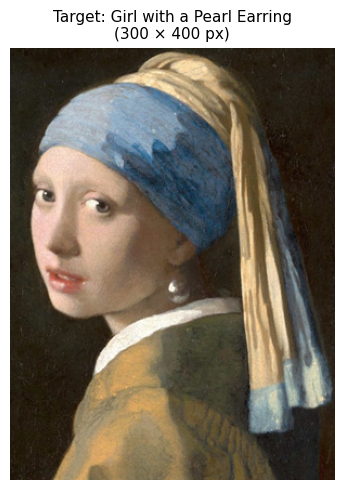

Image shape: (400, 300, 3)  |  dtype: uint8


In [ ]:
# Load target image
target = Image.open("../data/Girl_Pearl_Earing.png").convert("RGB")
target_arr = np.array(target)

fig, ax = plt.subplots(figsize=(4, 5))
ax.imshow(target_arr)
ax.axis("off")
ax.set_title("Target: Girl with a Pearl Earring\n(300 x 400 px)", fontsize=11)
plt.tight_layout()
plt.show()
print(f"Image shape: {target_arr.shape}  |  dtype: {target_arr.dtype}")

# 2. Representation

## 2.1. The Gene: Triangle

`Triangle` is the gene-level class of the GA, implemented in `triangle.py` as an immutable dataclass following a value object pattern: it is defined entirely by its data (`vertices` and `color`), has no identity beyond those values, and is never modified after creation. The class defines the gene's data fields, validation logic, geometric helper methods, factory methods for flexible initialisation, mutation methods for vertex and colour perturbation and serialisation utilities for checkpointing.

| Field | Type | Range | Description |
|---|---|---|---|
| `vertices` | $3 \times (x, y)$ float | $[0,W)\times[0,H)$ | Triangle vertex coordinates in pixel space |
| `color` | `(R,G,B,A)` int | $[0,255]^4$ | RGB color and alpha transparency |

**Key design choices in `triangle.py`:**

- **Immutability:** `Triangle` instances are immutable (`@dataclass(frozen=True, slots=True)`), enforced at the language level. Genetic operators therefore return new instances rather than modifying existing ones in place, simplifying state management and avoiding unintended side effects during evolution.

- **Continuous vertex space:** vertex coordinates are stored as floating-point values and discretised only at render time. This enables fine-grained geometric mutations and avoids cumulative precision loss from repeated integer rounding.

- **Alpha compositing:** the alpha channel enables semi-transparent overlap between primitives. During rendering, overlapping triangles blend through alpha compositing, allowing the population to approximate smooth colour transitions rather than only piecewise-constant regions.

- **Degeneracy detection:** `is_degenerate()` computes triangle area using the shoelace formula and flags near-collinear configurations (area < 1 $px^2$). Such triangles contribute negligibly to the rendered image and may be filtered or penalised during mutation.

In [3]:
sys.path.insert(0, "../src")
rng = np.random.default_rng(42)

# creating a triangle 
t = Triangle(
    vertices=((50.0, 80.0), (200.0, 30.0), (150.0, 250.0)),
    color=(70, 130, 180, 120)
)

print(" Triangle (gene) ")
print(f"  repr         : {t}")
print()
print(" Geometry ")
print(f"  vertices     : {t.vertices}")
print(f"  xs           : {t.xs}")
print(f"  ys           : {t.ys}")
print(f"  area         : {t.area():.1f}")
print(f"  bounding box : {t.bounding_box()}")
print(f"  degenerate   : {t.is_degenerate()}")
print()
print(" Colour ")
print(f"  color        : {t.color}  (R, G, B, A)")
print(f"  rgb          : {t.rgb}")
print(f"  alpha        : {t.alpha}")
print(f"  alpha_float  : {t.alpha_float:.3f}")
print()
print(" Immutability ")
try:
    t.color = (255, 0, 0, 255)
except Exception as e:
    print(f"  t.color = (255, 0, 0, 255)  ->  {type(e).__name__}")
    print(f"  Triangle is frozen — all operators must return new instances")

 Triangle (gene) 
  repr         : Triangle(vertices=[(50.0,80.0), (200.0,30.0), (150.0,250.0)], color=RGBA(70,130,180,120))

 Geometry 
  vertices     : ((50.0, 80.0), (200.0, 30.0), (150.0, 250.0))
  xs           : [ 50. 200. 150.]
  ys           : [ 80.  30. 250.]
  area         : 15250.0
  bounding box : (50, 30, 200, 250)
  degenerate   : False

 Colour 
  color        : (70, 130, 180, 120)  (R, G, B, A)
  rgb          : (70, 130, 180)
  alpha        : 120
  alpha_float  : 0.471

 Immutability 
  t.color = (255, 0, 0, 255)  ->  FrozenInstanceError
  Triangle is frozen — all operators must return new instances


## 2.2. The Chromosome: Individual

`Individual` is the chromosome-level class of the GA, implemented in `individual.py` following an encapsulation principle: it wraps an ordered sequence of exactly 100 `Triangle` objects and exposes only controlled interfaces for fitness access, chromosome manipulation and initialisation, hiding internal rendering and caching details from the rest of the system.

Draw order is semantically meaningful: index 0 is the bottom-most layer, index 99 is the top-most and occludes everything beneath it.

<div style="text-align:center; margin: 16px 0;">

$Individual = [Triangle_0, Triangle_1, ..., Triangle_{99}]$

</div>

This gives a total genome of $100 \times 7 = 700$ continuous parameters.

**Key design choices in `individual.py`:**

- **Lazy fitness caching:** rendering 100 alpha-composited layers is expensive. Fitness is computed once on first access and cached for the lifetime of the individual. The GA engine can call `.fitness` freely during sorting, selection and logging with zero redundant renders.
- **Immutability by design:** unlike `Triangle` which enforces immutability at the language level via `frozen=True`, `Individual` achieves it through disciplined encapsulation: the chromosome is stored as a private tuple and all crossover and mutation operators return new instances via `copy_with()` rather than modifying in place. This makes the generational loop easy to reason about — no individual is ever in an intermediate state.
- **Shared fitness function reference:**  the `FitnessFunction` object (which holds the target image array) is shared across all individuals in a population following a **flyweight** pattern, not copied. This keeps memory usage proportional to population size rather than population size × image size.

In [4]:
rng = np.random.default_rng(42)
target = np.array(Image.open("../data/Girl_Pearl_Earing.png").convert("RGB"))
fitness_fn = RMSEFitness(target)

# criação
ind = Individual.random(fitness_fn, rng)
print(" Individual ")
print(f"  repr             : {ind}")
print(f"  n_triangles      : {len(ind.triangles)}")
print(f"  is_evaluated     : {ind.is_evaluated()}")

# lazy caching
fitness = ind.fitness
print(f"\n  fitness (1st access, triggers render) : {fitness:.4f}")
print(f"  is_evaluated     : {ind.is_evaluated()}")
print(f"  fitness (2nd access, from cache)      : {ind.fitness:.4f}")

# imutabilidade
ind2 = ind.copy_with(triangles=list(ind.triangles))
print(f"\n  copy_with() -> new object : {ind is ind2}")
print(f"  fitness cache not transferred : {ind2.is_evaluated()}")

 Individual 
  repr             : Individual(triangles=100, fitness=not evaluated)
  n_triangles      : 100
  is_evaluated     : False

  fitness (1st access, triggers render) : 85.4575
  is_evaluated     : True
  fitness (2nd access, from cache)      : 85.4575

  copy_with() -> new object : False
  fitness cache not transferred : False


## 2.3. Initialisation Strategies

Initialisation determines the starting point of the search.  Following the Single Responsibility Principle, initialisation logic is distributed across the two classes presented above: `Triangle` defines how individual genes are constructed and `Individual` composes them into full chromosomes.

Six strategies are implemented, each encoding a different inductive bias about what constitutes a good starting point. 

| Strategy | Geometry | Colour | Key property |
|----------|----------|--------|--------------|
| `random` | Uniform random | Uniform random | Uniform random geometry and colour; maximum diversity |
| `random_semitransparent` | Uniform random | Uniform random, $\alpha \in [30, 120]$ | Restricts $\alpha$, encouraging layering of triangles from different opacities from the beginning |
| `random_small` | Clustered ($\leq 15\%$ canvas) | Uniform random | Generates small triangles by keeping vertices within 15\% of the canvas size from each other |
| `from_grid_random_color` | $10 \times 10$ grid + Gaussian noise | Uniform random | Guaranteed spatial coverage |
| `random_sorted_alpha` | Uniform random | Uniform random | Opaque triangles placed on lower layers |
| `random_quadrant` | Constrained per $5 \times 5$ cell | Uniform random | Guarantees per-region coverage |

The strategies form a natural spectrum from fully uninformed (`random`) to increasingly structured (`from_grid_random_color`, `random_quadrant`), and from unconstrained to deliberately biased (`random_semitransparent`, `random_small`, `random_sorted_alpha`). In grid-based strategies, vertex noise ($\sigma = 0.3 \times \text{cell\_size}$ by default) is applied per individual to ensure population diversity. Without it, all chromosomes would share identical triangle positions, causing immediate premature convergence.

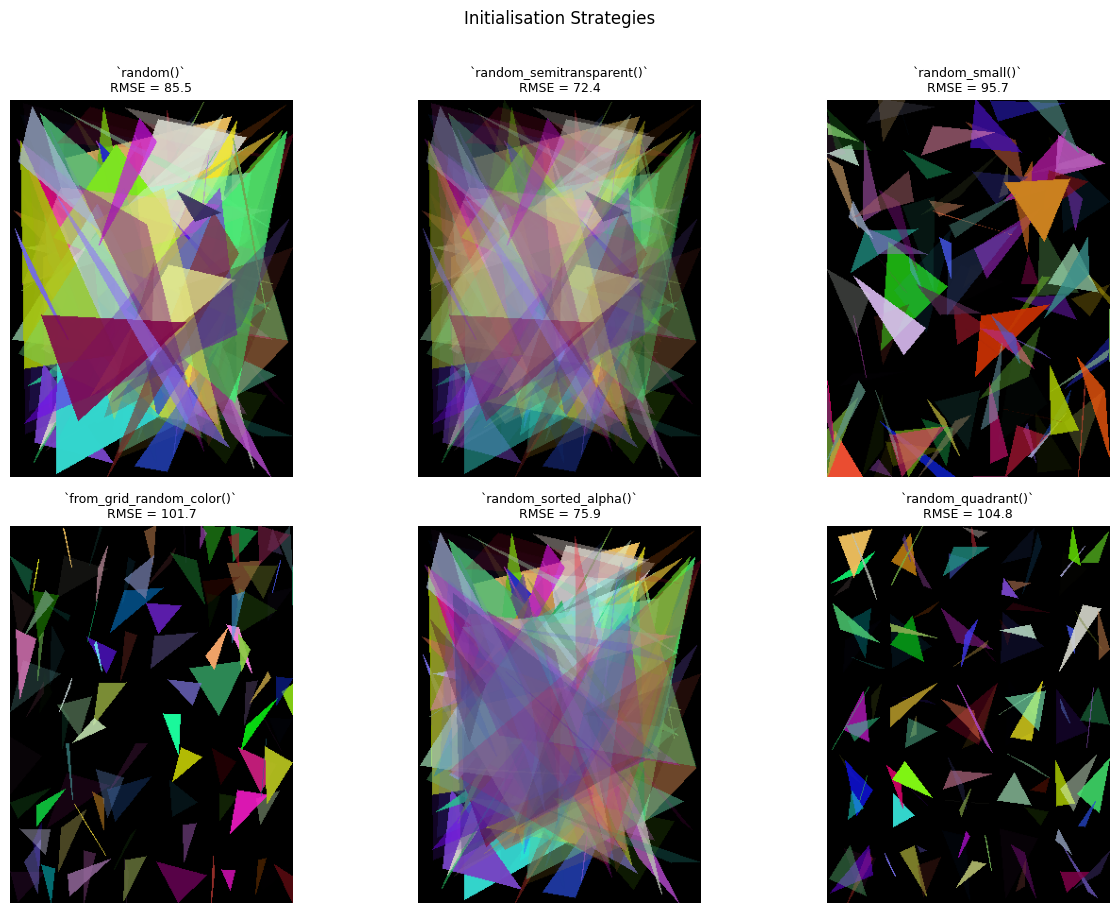

In [5]:
sys.path.insert(0, "../src")

rng_seed = 42
target = np.array(Image.open("../data/Girl_Pearl_Earing.png").convert("RGB"))
fitness_fn = RMSEFitness(target)

strategies = [
    ("random",                  lambda rng: Individual.random(fitness_fn, rng)),
    ("random_semitransparent",  lambda rng: Individual.random_semitransparent(fitness_fn, rng)),
    ("random_small",            lambda rng: Individual.random_small(fitness_fn, rng)),
    ("from_grid_random_color",  lambda rng: Individual.from_grid_random_color(fitness_fn, rng)),
    ("random_sorted_alpha",     lambda rng: Individual.random_sorted_alpha(fitness_fn, rng)),
    ("random_quadrant",         lambda rng: Individual.random_quadrant(fitness_fn, rng)),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
axes = axes.flatten()

for ax, (name, factory) in zip(axes, strategies):
    rng = np.random.default_rng(rng_seed)
    ind = factory(rng)
    rendered = render(ind.triangles)
    rmse = ind.fitness

    ax.imshow(rendered)
    ax.set_title(f"`{name}()`\nRMSE = {rmse:.1f}", fontsize=9, pad=6)
    ax.axis("off")

plt.suptitle("Initialisation Strategies", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# 3. Fitness Function

The fitness function quantifies how closely a candidate solution approximates the target image. It is implemented in `fitness.py` following the Strategy pattern: `FitnessFunction` is an abstract base class (ABC) that defines a single interface - `evaluate(candidate) -> float` - and the GA engine depends only on this abstraction, making the metric swappable without touching any other component.

**`RMSEFitness`** is the metric required by the project specification and used throughout our experiments:

$$\text{RMSE} = \sqrt{\frac{1}{H \times W \times C} \sum_{h,w,c} \left( I_{\text{rendered}}[h,w,c] - I_{\text{target}}[h,w,c] \right)^2}$$

The GA **minimises** this value: a perfect reconstruction scores 0, with a theoretical maximum of 255. The target image is converted to `float32` once at construction time and shared across all evaluations via the **flyweight** pattern, avoiding repeated casting in the computational hot path.

# 4. Rendering Pipeline

The rendering pipeline is the bridge between representation and fitness evaluation, converting a chromosome into a pixel array that can be compared against the target. It is implemented in `ga_utils.py`, which also serves as the single source of truth for canvas dimensions (`IMG_WIDTH = 300`, `IMG_HEIGHT = 400`). All other modules import these constants from here rather than hardcoding values.

The core function is `render()`, which follows a sequential layered compositing approach:


1. Initialise a solid black RGBA canvas ($300\times 400$ px)
2. For each triangle i in [0 ... 99]: 

   a. Create a blank transparent RGBA layer (same size as canvas)

   b. Draw the filled triangle onto that layer (PIL ImageDraw.polygon)- float vertices are rounded to integers only at this point

   c. Alpha-composite the layer onto the canvas (Porter-Duff "over"): 
         $out_RGB = \alpha \times src_RGB + (1 - \alpha) · dst_RGB4$

3. Convert final RGBA canvas -> RGB uint8 numpy array


**Key design choices in `ga_utils.py`:**

- **Per-triangle layer compositing:** PIL's `ImageDraw.polygon()` paints flat colour with no native alpha blending. To achieve true per-triangle transparency, each triangle is drawn onto its own blank RGBA layer and composited onto the canvas. This is the only technically correct approach, at the cost of one PIL image allocation per triangle per render.

- **Late vertex rounding:** float coordinates stored in `Triangle` are rounded to integer pixel positions only inside `render()`, at draw time. This preserves the full precision of continuous-space mutation throughout evolution.

- **RGB output only:** the final canvas drops the alpha channel before returning, since `FitnessFunction.evaluate()` operates on RGB arrays matched against the RGB target. Alpha is internal to the rendering process.

The module also provides I/O utilities (`load_target`, `save_render`), checkpoint helpers (`triangles_to_json`, `triangles_from_json`) and visualisation helpers (`side_by_side`, `render_triangles_pil`) used throughout the experimental pipeline.

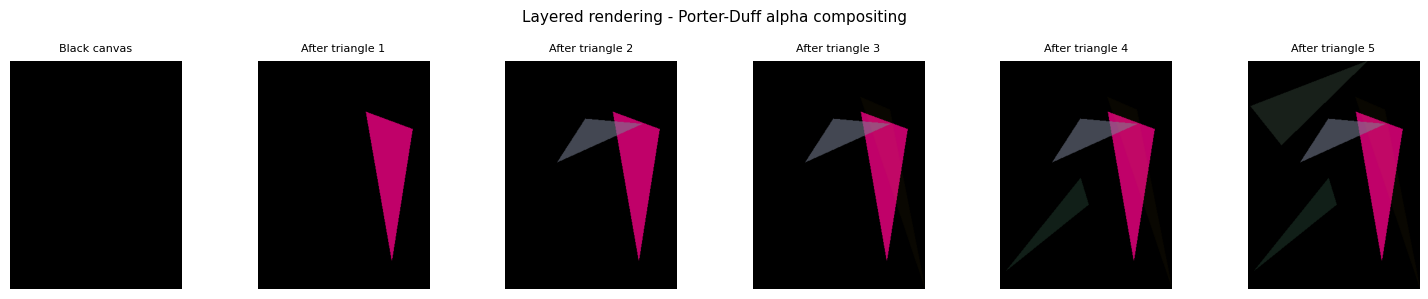

In [6]:
W, H = 300, 400
rng = np.random.default_rng(7)
demo_tris = [Triangle.random(W, H, rng) for _ in range(5)]

canvas = Image.new("RGBA", (W, H), (0, 0, 0, 255))
snapshots = [np.array(canvas.convert("RGB"))]

for tri in demo_tris:
    layer = Image.new("RGBA", (W, H), (0, 0, 0, 0))
    verts_px = [(int(round(x)), int(round(y))) for x, y in tri.vertices]
    ImageDraw.Draw(layer).polygon(verts_px, fill=tri.color)
    canvas = Image.alpha_composite(canvas, layer)
    snapshots.append(np.array(canvas.convert("RGB")))

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, (snap, ax) in enumerate(zip(snapshots, axes)):
    ax.imshow(snap); ax.axis("off")
    ax.set_title(f"After triangle {i}" if i > 0 else "Black canvas", fontsize=8)
plt.suptitle("Layered rendering - Porter-Duff alpha compositing", fontsize=11)
plt.tight_layout()
plt.show()


# 5. Genetic Operators

The genetic operators define how the population evolves from one generation to the next. All three operator families - selection, crossover and mutation - follow the Strategy pattern: each is defined by an abstract base class (ABC) with a single interface method and the GA engine depends exclusively on that abstraction. Concrete strategies are injected at construction time, making any combination of operators possible without modifying the engine.

All operators are stateless between calls, being the only mutable state RNG, which is always supplied by the caller. This makes them safe to reuse across generations and trivially testable in isolation.

## 5.1. Selection

Selection determines which individuals become parents for the next generation, directly governing the **exploration/exploitation trade-off**: high selection pressure accelerates convergence but risks premature convergence to a local optimum; low pressure preserves diversity but slows progress.

Three strategies are implemented in `selection.py`:

| Operator | Mechanism | Pressure | Key property |
|----------|-----------|----------|--------------|
| `TournamentSelection(k)` | Sample $k$ individuals, return the best | Controlled by $k$ | Robust, no fitness scaling required |
| `RankSelection(sp)` |Assigns probabilities by fitness rank rather than raw value | Controlled by $sp \in (1, 2]$ | Stable pressure regardless of fitness distribution |


**`TournamentSelection`** is the baseline choice. It requires no fitness scaling, is robust to outliers (a single very fit individual cannot dominate the pool) and exposes a single interpretable parameter: the tournament size $k$:

- $k = 2$: low pressure, preserves diversity
- $k = 3$: moderate pressure *(baseline)*
- $k = 5, 10$: increasing pressure, faster convergence but higher risk of premature convergence

**`RankSelection`** assigns selection probabilities based on fitness rank rather than raw values. It is particularly useful in later generations when fitness values cluster tightly and roulette-style selection would become nearly uniform.


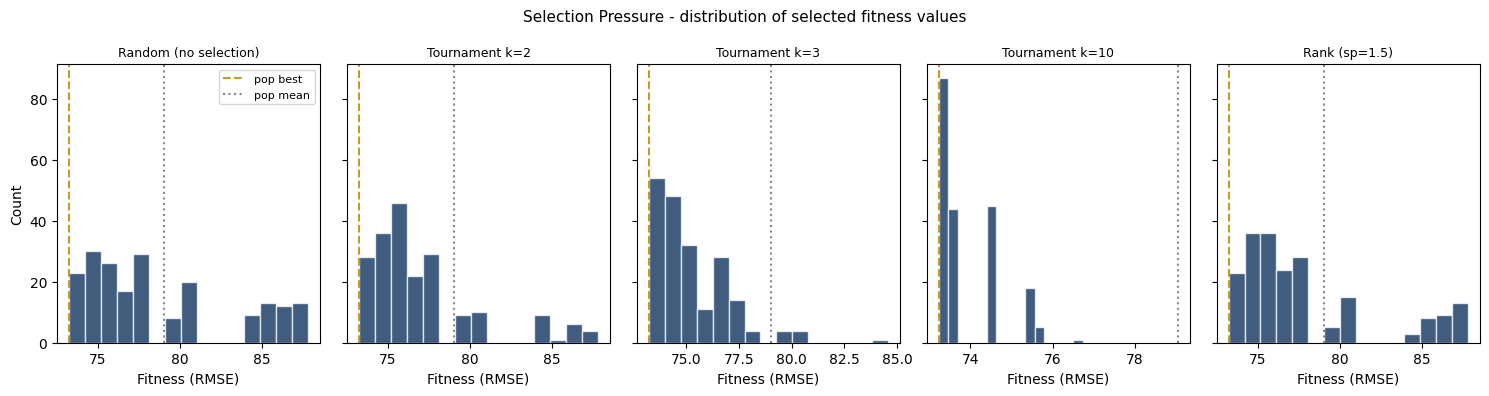

In [7]:
sys.path.insert(0, "../src/genetic_operators")
rng = np.random.default_rng(42)
target = np.array(Image.open("../data/Girl_Pearl_Earing.png").convert("RGB"))
fitness_fn = RMSEFitness(target)

# create a small population
population = [Individual.random(fitness_fn, rng) for _ in range(20)]
_ = [ind.fitness for ind in population]  # trigger evaluation

fitnesses = [ind.fitness for ind in population]

# compare selection pressure across operators
operators = [
    ("Random (no selection)", None),
    ("Tournament k=2",  TournamentSelection(tournament_size=2)),
    ("Tournament k=3",  TournamentSelection(tournament_size=3)),
    ("Tournament k=10", TournamentSelection(tournament_size=10)),
    ("Rank (sp=1.5)",   RankSelection(selection_pressure=1.5)),
]

n_selections = 200
fig, axes = plt.subplots(1, len(operators), figsize=(15, 4), sharey=True)

for ax, (label, op) in zip(axes, operators):
    if op is None:
        selected_f = [population[rng.integers(0, len(population))].fitness
                      for _ in range(n_selections)]
    else:
        selected = op.select(population, n_parents=n_selections, rng=rng)
        selected_f = [ind.fitness for ind in selected]

    ax.hist(selected_f, bins=15, color="#002654", alpha=0.75, edgecolor="white")
    ax.axvline(min(fitnesses), color="#C49A28", lw=1.5, linestyle="--", label="pop best")
    ax.axvline(np.mean(fitnesses), color="#888", lw=1.5, linestyle=":", label="pop mean")
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Fitness (RMSE)")
    if ax == axes[0]:
        ax.set_ylabel("Count")

axes[0].legend(fontsize=8)
plt.suptitle("Selection Pressure - distribution of selected fitness values", fontsize=11)
plt.tight_layout()
plt.show()

## 5.2. Crossover

Crossover combines the chromosomes of two parents to produce two offspring, with the goal of preserving and recombining beneficial building blocks. Because draw order is semantically meaningful in this problem (bottom-to-top rendering, occlusion), operators that preserve contiguous chromosome segments may produce more visually coherent offspring and so they must be tested.

Five strategies are implemented in `crossover.py`:

| Operator | Mechanism | Locality | Notes |
|----------|-----------|----------|-------|
| `SinglePointCrossover` | One random cut point; everything after it is exchanged between parents | High | Preserves contiguous blocks |
| `UniformCrossover`$(p)$| Per-gene swap with probability $p$ | Low | Maximum mixing, destroys locality |
| `KPointCrossover`$(k)$ | $k$ cut points; preserves smaller blocks while allowing more recombination | Medium | Generalises single-point |
| `SegmentShuffleCrossover` | Random number of cuts $k \in [k_{\min}, k_{\max}]$ cuts; each segment independently assigned to a child  | Medium | Variable granularity per call |
| `BlendCrossover` $(\alpha)$ |Interpolates parents' genes to create new triangles and extends by $\alpha$ (Eshelman & Schaffer, 1993) | Continuous | Only operator that can create parameter values not present in either parent |

<br>

> **Locality:** refers to how well a crossover operator preserves genes that are adjacent in the chromosome. High locality means neighbouring genes tend to be inherited together; low locality means each gene is inherited independently of its neighbours.

We use as baseline the **`UniformCrossover`** since it makes no assumptions about gene ordering and provides the highest mixing rate. We later  test whether locality-preserving operators (`SinglePointCrossover`, `KPointCrossover`) outperform it for this problem.

**`BlendCrossover`** (BLX-$\alpha$, Eshelman & Schaffer, 1993) is the only operator that can generate parameter values outside the range of the two parents, sampling offspring vertices and colours from $[\min - \alpha \cdot I,\ \max + \alpha \cdot I]$ where $I = \max - \min$. With $\alpha = 0$ offspring always lie between the parents; with $\alpha = 0.5$ (default) they may extend up to 50% beyond.


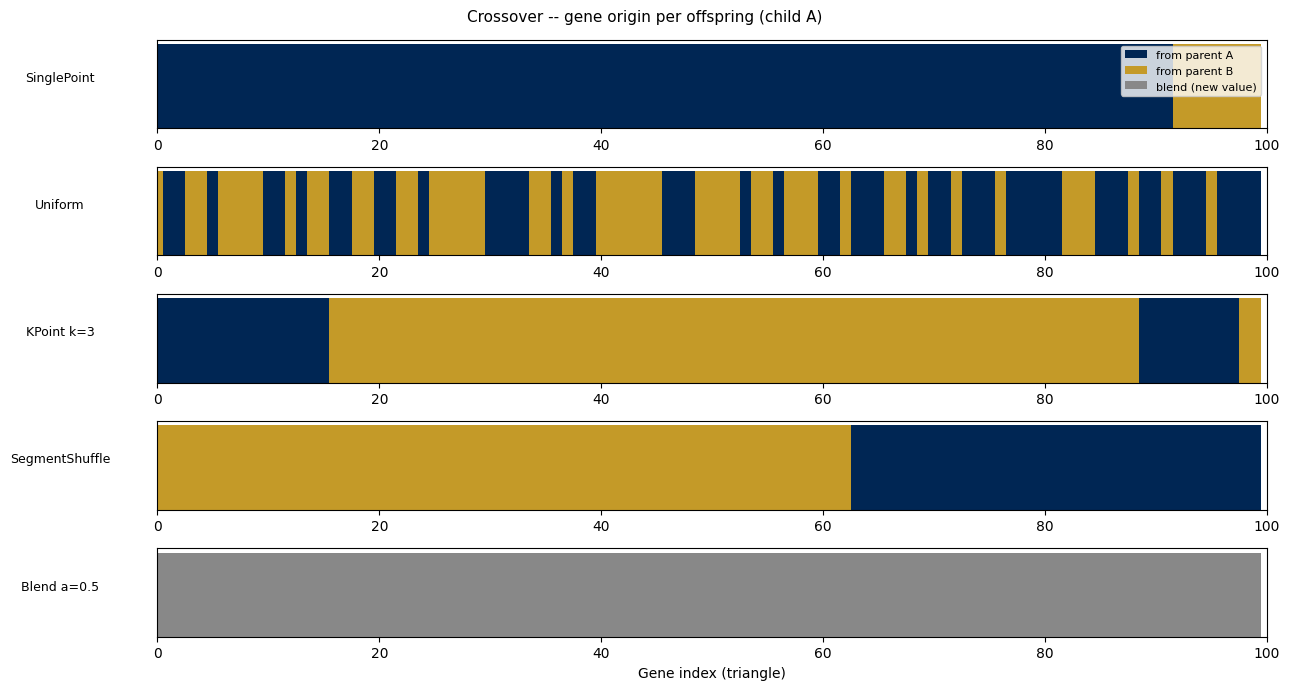

In [8]:
rng = np.random.default_rng(42)
parent_a = Individual.random(fitness_fn, rng)
parent_b = Individual.random(fitness_fn, rng)

operators = [
    ("SinglePoint",     SinglePointCrossover()),
    ("Uniform",         UniformCrossover(swap_prob=0.5)),
    ("KPoint k=3",      KPointCrossover(k=3)),
    ("SegmentShuffle",  SegmentShuffleCrossover(k_min=1, k_max=5)),
    ("Blend a=0.5",     BlendCrossover(alpha=0.5)),
]

fig, axes = plt.subplots(len(operators), 1, figsize=(13, 7))

for ax, (label, op) in zip(axes, operators):
    child_a, child_b = op.cross(parent_a, parent_b, rng)

    origin_a = []
    for i, tri in enumerate(child_a.triangles):
        if tri in parent_a.triangles:
            origin_a.append("A")
        elif tri in parent_b.triangles:
            origin_a.append("B")
        else:
            origin_a.append("?")  # blend crossover -- new value

    colors = ["#002654" if o == "A" else "#C49A28" if o == "B" else "#888"
              for o in origin_a]

    ax.bar(range(100), [1]*100, color=colors, width=1.0, edgecolor="none")
    ax.set_xlim(0, 100)
    ax.set_yticks([])
    ax.set_ylabel(label, fontsize=9, rotation=0, labelpad=70)
    ax.set_xlabel("Gene index (triangle)" if ax == axes[-1] else "")

legend_elements = [
    Patch(facecolor="#002654", label="from parent A"),
    Patch(facecolor="#C49A28", label="from parent B"),
    Patch(facecolor="#888",    label="blend (new value)"),
]
axes[0].legend(handles=legend_elements, loc="upper right", fontsize=8)
plt.suptitle("Crossover -- gene origin per offspring (child A)", fontsize=11)
plt.tight_layout()
plt.show()

## 5.3. Mutation

Mutation introduces variation that crossover alone cannot provide, being the primary mechanism for escaping local optima. The **mutation rate** is applied per triangle, not per individual: at `mutation_rate=0.05`, each of the 100 triangles has an independent 5% chance of being mutated, producing on average 5 modified triangles per individual per generation.

Five concrete operators are implemented in `mutation.py`:

| Operator | What it perturbs | Search character |
|----------|-----------------|-----------------|
| `GaussianMutation`$(\sigma, rate)$ | Vertices + colour with Gaussian noise $\mathcal{N}(0, \sigma^2)$ | Local refinement  |
| `CreepMutation`$(\delta, rate)$ | Vertices + colour with bounded uniform noise $\mathcal{U}(-\delta, +\delta)$ | Fine local search, no outlier jumps |
| `ResetMutation`$(rate)$ | Replaces selected triangles with entirely new random ones | Coarse exploration, diversity injection |
| `SwapMutation`$(rate, n)$ | Swaps draw-order positions of $n$ triangle pairs | Explores ordering space only |
| `CompositeMutation`$(ops)$ | Applies multiple operators in sequence | Combined fine + coarse search |

Four adaptive decay schedulers extend the operators above by annealing noise parameters over generations:

| Scheduler | Targets | Behaviour |
|-----------|---------|-----------|
| `SigmaDecayScheduler` | `GaussianMutation` | Exponential decay of both $\sigma$ values from max to min over all generations |
| `DeltaDecayScheduler` | `CreepMutation` | Identical decay logic applied to $\delta$ parameters |
| `AsymmetricSigmaDecayScheduler` | `GaussianMutation` | Decays vertex and colour $\sigma$ at independent rates - colour stabilises at 50% of generations by default, vertices decay over the full run |
| `CompositeSigmaDecayScheduler` | `GaussianMutation` inside `CompositeMutation` | Same exponential decay logic, targeting the inner Gaussian operator by reference |

**`GaussianMutation`** is the baseline operator, implementing local search: small $\sigma$ values refine an already-good solution; larger values allow bigger jumps. The `set_sigma()` method allows $\sigma$ to be updated in place each generation, enabling adaptive mutation without reconstructing the operator object.

**`CreepMutation`** is structurally similar to `GaussianMutation` but uses bounded uniform noise. Knowing that large outlier jumps are structurally impossible, this mutations makes it more conservative and better suited to late-stage refinement when triangles are already well-placed.

**`CompositeMutation`** chains operators in sequence (output of operator $i$ feeds into operator $i+1$), combining `GaussianMutation` for fine-grained local search with `ResetMutation` for coarse exploration and `SwapMutation` for draw-order optimisation - all within a single unified call to the engine.

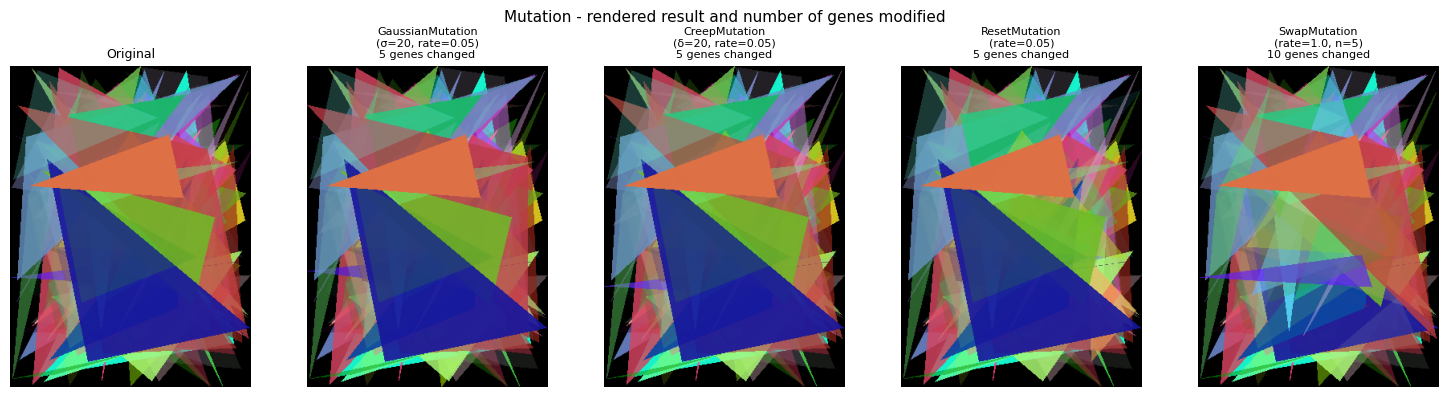

In [ ]:

rng = np.random.default_rng(0)
original = Individual.random(fitness_fn, rng)

operators = [
    ("GaussianMutation\n(σ=20, rate=0.05)", GaussianMutation(mutation_rate=0.05, vertex_sigma=20, color_sigma=20)),
    ("CreepMutation\n(δ=20, rate=0.05)", CreepMutation(mutation_rate=0.05, vertex_delta=20, color_delta=20)),
    ("ResetMutation\n(rate=0.05)", ResetMutation(mutation_rate=0.05)),
    ("SwapMutation\n(rate=1.0, n=5)", SwapMutation(mutation_rate=1.0, n_swaps=5)),
]

fig, axes = plt.subplots(1, len(operators) + 1, figsize=(15, 4))

axes[0].imshow(render(original.triangles))
axes[0].set_title("Original", fontsize=9)
axes[0].axis("off")

for ax, (label, op) in zip(axes[1:], operators):
    mutated = op.mutate(original, np.random.default_rng(1))

    # highlight changed triangles
    changed = [i for i, (t1, t2) in enumerate(zip(original.triangles, mutated.triangles))
               if t1 != t2]

    rendered = render(mutated.triangles)
    ax.imshow(rendered)
    ax.set_title(f"{label}\n{len(changed)} genes changed", fontsize=8)
    ax.axis("off")

plt.suptitle("Mutation - rendered result and number of genes modified", fontsize=11)
plt.tight_layout()
plt.show()

# 6. Evolutionary Engine

The GA engine is implemented across two classes - `Population` (`population.py`) and `GeneticAlgorithm` (`ga.py`) - following a clear separation of concerns: `Population` manages the collection of individuals and exposes evaluation, statistics, diversity and replacement logic; `GeneticAlgorithm` orchestrates the evolutionary loop using injected operator strategies.

## 6.1. Population

`Population` is a container for a single generation of `Individual` objects, implemented in `population.py`. Following the Single Responsibility Principle, it does not implement the evolutionary loop and instead encapsulates four concerns: initialisation, evaluation, statistics and diversity tracking, and generational replacement.

**Key design choices:**

- **Lazy sorted order:** after every `evaluate()` call, individuals are sorted ascending by fitness. This makes `best` and `worst` access $O(1)$ and avoids repeated sorting in the engine.

- **Parallel evaluation:** fitness evaluation is opt-in parallel via `ThreadPoolExecutor`. PIL rendering releases the GIL (I/O-bound), making threads effective without multiprocessing overhead. Serial evaluation is the default — parallel is only beneficial for populations $\geq 50$ due to thread overhead.

- **Elitism in replacement:** `replace(offspring, n_elites)` carries the top $k$ individuals from the current generation forward unchanged before filling remaining slots with offspring. Elitism guarantees the best solution found is never lost to random variation. Even $k=1$ significantly stabilises convergence by preventing regression — but high elitism values risk reducing population diversity by repeatedly propagating the same genetic material.

- **Diversity metrics:** four metrics are exposed:

  | Metric | Type | Formula | Logged |
  |--------|------|---------|--------|
  | Phenotypic variance | Fitness spread | $V(P) = \frac{1}{m-1}\sum_{i=1}^{m}(f_i - \bar{f})^2$ | Every generation |
  | Genotypic variance | Chromosome spread | $V(P) = \frac{1}{m-1}\sum_{i=1}^{m}(d_i - \bar{d})^2$ | Every 10 generations |
  | Phenotypic entropy | Fitness distribution | $H(P) = \sum_j F_j \log F_j$ | On demand |
  | Genotypic entropy | Genotype distribution | $H(P) = \sum_j F_j \log F_j$ | On demand |

  where $d_i$ is the normalised L2 distance from individual $i$'s chromosome to the best individual's chromosome. Chromosome vectors are normalised before computing distances so that vertex coordinates (range $[0, 400]$) and colour channels (range $[0, 255]$) contribute on comparable scales.

- **Population size and diversity:** `population_size` is a primary driver of genetic diversity - larger populations maintain more parallel search threads and reduce the probability of premature convergence, at the cost of more fitness evaluations per generation. In our experiments we firstly use $N = 50$, which balances diversity against computational budget. The interaction between population size, elitism and selection pressure is studied in our final tests.

## 6.2. GA Engine

The `GeneticAlgorithm` class orchestrates the full evolutionary loop. It depends exclusively on abstract operator interfaces (`SelectionOperator`, `CrossoverOperator`, `MutationOperator`) injected at construction - a dependency injection pattern that makes the engine agnostic to which concrete operators are active.

**Generational loop:**

```
INITIALISE population (N individuals, chosen init_strategy)
EVALUATE all individuals

FOR generation g = 1 … G:
    1. Log statistics (best, mean, std, diversity)
    2. Check early stopping
    3. SELECT 2 × n_pairs parents
    4. For each pair:
         if rng < crossover_rate -> CROSSOVER -> (child_a, child_b)
         else -> copy parents unchanged
         MUTATE child_a and child_b
    5. REPLACE population (offspring + n_elites from current generation)
    6. EVALUATE new offspring
    7. Fire callback (e.g. sigma decay scheduler)

RETURN best individual found across all generations
```

**`GAConfig`: hyperparameter configuration:**

`GAConfig` centralises all hyperparameters in a dataclass with sensible defaults, primarily to allow the class to be instantiated and tested in isolation. The actual experimental values used in our study are defined in `runner.py` and overrride these defaults: 

| Parameter | Default | Description |
|-----------|---------|-------------|
| `population_size` | 50 | Individuals per generation |
| `n_generations` | 500 | Maximum generations (overridden to 3000 in runner) |
| `crossover_rate` | 0.8 | Per-pair crossover probability |
| `n_elites` | 1 | Individuals carried forward unchanged (overridden per phase in runner) |
| `n_workers` | 1 | Threads for parallel fitness evaluation |
| `seed` | `None` | Fixed per-run in the runner to 42, 43, or 44 |

**Early stopping:** two mechanisms prevent wasted compute:

- **`EarlyStopping`** - stops if best fitness does not improve by more than `tolerance` over `patience` consecutive generations.
- **`DiversityAwareEarlyStopping`** - requires fitness stagnation **and** diversity collapse before stopping. If fitness is stuck but the population is still genetically diverse, the stagnation counter resets and the algorithm is given more time to exploit remaining diversity. Diversity collapse is signalled when either phenotypic or genotypic variance falls below configurable thresholds.

**Checkpointing:** the best individual is saved every `checkpoint_interval` generations as both a JSON (for reloading) and a PNG (for visual inspection), protecting against data loss during long runs.

**Callback system:** `run()` accepts an optional callback fired at the end of every generation with signature `callback(generation, best, stats)`. This is how the sigma/delta decay schedulers integrate with the engine - passed as callbacks, they update operator parameters in place each generation without the engine needing to know about them.

In [ ]:
sys.path.insert(0, "../src")

rng_demo = np.random.default_rng(42)
target = np.array(Image.open("../data/Girl_Pearl_Earing.png").convert("RGB"))
fitness_fn = RMSEFitness(target)

# Assemble the GA with baseline operators 
ga = GeneticAlgorithm(
    fitness_fn = fitness_fn,
    selection  = TournamentSelection(tournament_size=3),
    crossover  = UniformCrossover(),
    mutation   = GaussianMutation(mutation_rate=0.05, vertex_sigma=15, color_sigma=15),
    config     = GAConfig(
        population_size = 10,        # small for demonstration purposes
        n_generations   = 20,
        n_elites        = 1,
        crossover_rate  = 0.8,
        early_stopping  = EarlyStopping(patience=10),
        seed            = 42,
    )
)

best = ga.run(init_strategy="random")

print(f"Best RMSE after {len(ga.generation_log)-1} generations: {best.fitness:.4f}")
print(f"Log entries: {len(ga.generation_log)}")
print(f"\nFirst 3 generations:")
for entry in ga.generation_log[:3]:
    print(f"  gen {entry['generation']:>3} | best={entry['best']:.4f} | "
          f"mean={entry['mean']:.4f} | diversity={entry['diversity']:.6f}")

Best RMSE after 20 generations: 65.7129
Log entries: 21

First 3 generations:
  gen   0 | best=73.2346 | mean=78.3369 | diversity=17.205687
  gen   1 | best=73.0195 | mean=74.8053 | diversity=2.377726
  gen   2 | best=72.1022 | mean=73.5086 | diversity=0.925396


# 7. Experimental Pipeline

The experimental pipeline is orchestrated by `runner.py`, which translates high-level experiment descriptions into reproducible GA runs and structured outputs. Each configuration is defined as a `RunConfig` dataclass - a declarative record of operator choices, hyperparameters, and metadata - and executed across multiple seeds via `execute_single_run()`.

Run `python runner.py --target data/girl_pearl.png` to execute the full experiment.

## 7.1. Output Structure

Every run produces a structured directory tree under `runner_outputs/`:

```
runner_outputs/
├── results.csv                       <- global results table, one row per (config, seed) run
└── <config_name>/
    ├── config_results.csv            <- same columns as results.csv, filtered to this config
    └── seed_42/
        ├── config.json               <- full RunConfig (operators, hyperparams, seed)
        ├── ga_config.json            <- GAConfig dataclass serialised to JSON
        ├── generation_log.json       <- per-generation stats (see below)
        ├── best_final.png            <- rendered best individual at end of run
        ├── best_final_triangles.json <- chromosome of best individual (reloadable)
        └── checkpoints/
            ├── gen_0000.png
            ├── gen_0000_metrics.json
            ├── gen_0100.png
            ├── gen_0100_metrics.json
            └── ...
```

**`generation_log.json`** contains one entry per generation with the following fields:

| Field | Description |
|-------|-------------|
| `generation` | Generation index |
| `elapsed_s` | Wall-clock time since run start |
| `best` | Best RMSE in the population |
| `mean` | Mean RMSE across all individuals |
| `std` | Standard deviation of RMSE |
| `worst` | Worst RMSE in the population |
| `diversity` | Phenotypic variance (primary diversity signal) |

Checkpoint metrics JSONs (`gen_XXXX_metrics.json`) are saved every 100 generations and extend the generation log with the full diversity report.

This separation allows lightweight per-generation logging (fitness only) without the overhead of computing the full chromosome matrix every generation, while still preserving the complete diversity profile at regular intervals for post-hoc analysis.

**`results.csv`** is the primary analysis table: one row per (config, seed) run, containing the final best fitness, number of generations actually run, elapsed time and all operator/hyperparameter choices. At the end of the full experiment, this file aggregates all runs across all phases.

## 7.2. One Factor At a Time Configurations Structure

### 7.2.1. OFAT Rationale

The first five phases follow a **One Factor At a Time (OFAT)** protocol: each phase varies a single component while holding all others fixed at the best value found so far. This isolates each operator's contribution to final fitness.

We recognise the limitations of OFAT: because each phase fixes all components at the best value found so far, early decisions are made with later components still at their defaults. For instance, the optimal elite count found in Phase 2 was determined under the baseline selection method — once a better selection operator is found in Phase 3, that elite count may no longer be optimal. Phases 8–11 address this with targeted interaction checks and a grid search.

Each configuration is run with **3 seeds (42, 43, 44)**. Because GAs are stochastic, a single run may reflect a lucky initialisation rather than the true performance of a configuration. Three runs allow us to report mean $\pm$ std and detect gross outliers. We acknowledge that 3 runs provides limited statistical power. Running 30 or more replicates would be the gold standard, but it was not feasible given the computational constraints of this project.


| Phase | What varies | Fixed at |
|-------|-------------|----------|
| 1 | (baseline) | Tournament k=3, Uniform XO, Gaussian fixed, 5 elites |
| 2 | `n_elites` in {0, 1, 3, 5} | Baseline operators |
| 3 | Selection operator | 5 elites (baseline); best elites not carried forward — see note |
| 4 | Crossover operator | Best from previous phases |
| 5 | Mutation operator | Best from previous phases |

### 7.2.1. OFAT Configurations

- **Phase 1 - Baseline**
The baseline configuration was chosen to represent the most common neutral choices in the GA literature:

| Component | Choice | Rationale |
|-----------|--------|-----------|
| Selection | `TournamentSelection(k=3)` | Default; moderate pressure, robust |
| Crossover | `UniformCrossover` | No assumptions about gene ordering |
| Mutation | `GaussianMutation` (fixed $\sigma$) | Natural choice for continuous parameter spaces |
| Elites | 5 | Preserves top solutions without dominating offspring pool |

- **Phase 2 - Elitism sweep:** tests $n_elites \in \{0, 1, 3, 5\}$ to quantify the effect of elitism on convergence speed and final fitness.

- **Phase 3 - Selection sweep:** tests `TournamentSelection` with $k \in \{2, 5, 10\}$ and `RankSelection`, holding all else at baseline.

- **Phase 4 - Crossover sweep:** tests all five crossover operators (`UniformCrossover`, `SinglePointCrossover`, `KPointCrossover(k=2)`, `SegmentShuffleCrossover`, `BlendCrossover`), carrying forward the best selection operator from Phase 3.

- **Phase 5 - Mutation sweep:** tests seven mutation configurations (`gaussian_fixed`, `creep_fixed`, `gaussian_decay`, `creep_decay`, `composite_gaussian`, `composite_creep`, `composite_gaussian_decay`), carrying forward the best selection and crossover from the previous phases.

## 7.3. Post-OFAT Refinement Phases

Following the OFAT study, six additional phases test combinations and hyperparameter interactions that OFAT cannot capture:

| Phase | Description |
|-------|-------------|
| 6 | Best configuration from Phases 3–5 extended to 20 000 generations (convergence ceiling) |
| 7 | Initialisation strategy sweep (6 strategies, best operators from Phases 3–5) with 500 generations|
| 8 | Elitism re-test with best operators from Phases 3–5 (3000 generations)|
| 9 | Interaction check: `TournamentSelection` ($k=5$) with best mutations (3000 generations)|
| 10 | Grid search over `mutation_rate` $\times$ `vertex_sigma_max` (3000 generations)|
| 11 | Population size sweep ($N \in \{100, 150\}$) with best configuration (3000 generations)|
| 12 | Best configuration with $N \in \{150, 300\}$ and 20 000 generations |

<br>

> **Note:** Phases 13 and 14 are not analysed in this notebook. Phase 13 (alternative fitness functions: CIEDE2000 and SSIM) is analysed in `Challenge1_Analysis_NB.ipynb`; Phase 14 (generalisation to unseen images: Mona Lisa and a Nadir Afonso painting) is analysed in `Additional_Insights_NB.ipynb`.

# 8. Results

This section presents the quantitative results across all phases. For each phase, we compare configurations by final RMSE (mean ± std across 3 seeds) and assess statistical significance using the Mann-Whitney U test ($\alpha = 0.05$).

In [11]:
sys.path.insert(0, "../src")
sys.path.insert(0, "..")

OUTPUT_ROOT = "../runner_outputs"
RESULTS_CSV = os.path.join(OUTPUT_ROOT, "results.csv")

SEEDS  = [42, 43, 44]
COLORS = ["#002654", "#C49A28", "#C44E52", "#55A868", "#8172B2", "#64B5CD", "#E07B39", "#B4726A", "#8C8C8C"]

plt.rcParams.update({
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        120,
})

# load results
def load_results(path=RESULTS_CSV):
    if not os.path.exists(path):
        print("results.csv not found — run the runner first.")
        return []
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

def group_by_config(rows):
    grouped = defaultdict(list)
    for r in rows:
        grouped[(int(r["phase"]), r["run_name"])].append(float(r["final_best_fitness"]))
    return grouped
    
def load_generation_log(config_name, seed):
    path = os.path.join(OUTPUT_ROOT, config_name, f"seed_{seed}", "generation_log.json")
    if not os.path.exists(path):
        return None
    if os.path.getsize(path) == 0:
        return None
    with open(path, encoding="utf-8") as f:
        try:
            return json.load(f)
        except json.JSONDecodeError:
            return None

def load_metrics_log(config_name, seed):
    ckpt_dir = os.path.join(OUTPUT_ROOT, config_name, f"seed_{seed}", "checkpoints")
    if not os.path.isdir(ckpt_dir):
        return []
    entries = []
    for fname in sorted(os.listdir(ckpt_dir)):
        if not fname.endswith("_metrics.json"):
            continue
        fpath = os.path.join(ckpt_dir, fname)
        if os.path.getsize(fpath) == 0:
            continue
        with open(fpath, encoding="utf-8") as f:
            try:
                entries.append(json.load(f))
            except json.JSONDecodeError:
                continue
    return sorted(entries, key=lambda e: e["generation"])

rows    = load_results()
grouped = group_by_config(rows)

print(f"Loaded {len(rows)} runs across {len(grouped)} configurations.")

Loaded 120 runs across 53 configurations.


In [ ]:
# Plotting functions

STANDARD_FIGSIZE = (12, 3.5)  # shared figsize for all phase plots


def _short_label(config_name, prefix_parts=2):
    """Strip the pN_ prefix from a config name for axis labels."""
    parts = config_name.split("_", prefix_parts)
    return parts[-1] if len(parts) > 1 else config_name


def plot_convergence(phase, title, configs=None, figsize=STANDARD_FIGSIZE, label_map=None):
    phase_configs = [
        (name, fits)
        for (ph, name), fits in grouped.items()
        if ph == phase and (configs is None or name in configs)
    ]
    if not phase_configs:
        print(f"No results for Phase {phase}")
        return

    fig, ax = plt.subplots(figsize=figsize)
    for i, (config_name, _) in enumerate(phase_configs):
        color = COLORS[i % len(COLORS)]
        all_curves = []
        for seed in SEEDS:
            log = load_generation_log(config_name, seed)
            if log:
                curve = [entry["best"] for entry in log]
                ax.plot(curve, color=color, alpha=0.2, lw=0.9)
                all_curves.append(curve)
        if all_curves:
            min_len    = min(len(c) for c in all_curves)
            mean_curve = np.mean([c[:min_len] for c in all_curves], axis=0)
            label = label_map[config_name] if label_map and config_name in label_map else _short_label(config_name)
            ax.plot(mean_curve, color=color, lw=2.0, label=label)

    ax.set_xlabel("Generation")
    ax.set_ylabel("Best RMSE")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_bar_summary(phase, title, configs=None, figsize=STANDARD_FIGSIZE, label_map=None):
    phase_configs = [
        (name, fits)
        for (ph, name), fits in sorted(grouped.items())
        if ph == phase and (configs is None or name in configs)
    ]
    if not phase_configs:
        print(f"No results for Phase {phase}")
        return

    labels = [
        label_map[n] if label_map and n in label_map else _short_label(n)
        for n, _ in phase_configs
    ]
    means  = [np.mean(f) for _, f in phase_configs]
    stds   = [np.std(f)  for _, f in phase_configs]
    bests  = [np.min(f)  for _, f in phase_configs]

    x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x, means, yerr=stds, capsize=4,
           color="#002654", alpha=0.75, edgecolor="white", width=0.5)
    ax.scatter(x, bests, color="#C49A28", zorder=5, s=60, label="best seed")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Final RMSE")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    ranked = sorted(zip(labels, means, stds, bests), key=lambda t: t[1])
    print(f"\n{'Config':<35} {'Mean':>8} {'Std':>8} {'Best':>8}")
    print("-" * 62)
    for label, mean, std, best in ranked:
        print(f"{label:<35} {mean:>8.4f} {std:>8.4f} {best:>8.4f}")

def plot_diversity(config_name, seed=42, title=None, figsize=STANDARD_FIGSIZE):
    """
    Dual-axis plot: best RMSE (left) vs phenotypic variance (right) over generations.
    Uses checkpoint metrics files; falls back to generation_log if checkpoints are missing.
    """
    metrics = load_metrics_log(config_name, seed)
    if not metrics:
        log = load_generation_log(config_name, seed)
        if not log:
            print(f"No data found for {config_name} seed {seed}")
            return
        gens      = [e["generation"] for e in log]
        best_fit  = [e["best"]       for e in log]
        diversity = None
    else:
        gens      = [e["generation"]         for e in metrics]
        best_fit  = [e["best_fitness"]        for e in metrics]
        diversity = [e["phenotypic_variance"] for e in metrics]

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.plot(gens, best_fit, color="#002654", lw=2, label="Best RMSE")
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Best RMSE", color="#002654")
    ax1.set_title(title or config_name, fontsize=11)
    ax1.grid(alpha=0.25)

    lines, labels = ax1.get_legend_handles_labels()

    if diversity is not None:
        ax2 = ax1.twinx()
        ax2.plot(gens, diversity, color="#C49A28", lw=1.5, alpha=0.8, label="Phenotypic variance")
        ax2.set_ylabel("Phenotypic Variance", color="#C49A28")
        l2, lb2 = ax2.get_legend_handles_labels()
        lines  += l2
        labels += lb2

    ax1.legend(lines, labels, fontsize=9, loc="upper right")
    plt.tight_layout()
    plt.show()


def plot_seed_spread(phase, config_name, figsize=STANDARD_FIGSIZE):
    """
    Per-seed convergence curves for a single config to visualise run-to-run variance.
    Useful to check whether a result is consistent or driven by one lucky seed.
    """
    fig, ax = plt.subplots(figsize=figsize)
    for seed, color in zip(SEEDS, COLORS):
        log = load_generation_log(config_name, seed)
        if log:
            curve = [e["best"] for e in log]
            ax.plot(curve, color=color, lw=1.8, label=f"seed {seed}")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Best RMSE")
    ax.set_title(f"{_short_label(config_name)} - per-seed spread", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_final_image(config_name, seed=42, target_path="../data/Girl_Pearl_Earing.png", figsize=(6, 4)):
    """
    Display the best_final.png side by side with the original target image.
    figsize controls the total figure size, e.g. figsize=(5, 3) for smaller, (8, 5) for larger.
    """
    from PIL import Image
    result_path = os.path.join(OUTPUT_ROOT, config_name, f"seed_{seed}", "best_final.png")
    if not os.path.exists(result_path):
        print(f"Image not found: {result_path}")
        return

    result_img = Image.open(result_path)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    if os.path.exists(target_path):
        target_img = Image.open(target_path).convert("RGB")
        axes[0].imshow(target_img)
        axes[0].set_title("Original", fontsize=10)
    else:
        axes[0].text(0.5, 0.5, "target not found", ha="center", va="center")
        axes[0].set_title("Original", fontsize=10)

    axes[1].imshow(result_img)
    axes[1].set_title(f"{_short_label(config_name)}  seed={seed}", fontsize=10)

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


## 8.1. OFAT Results (per phase)

### 8.1.1. Baseline Results Analysis

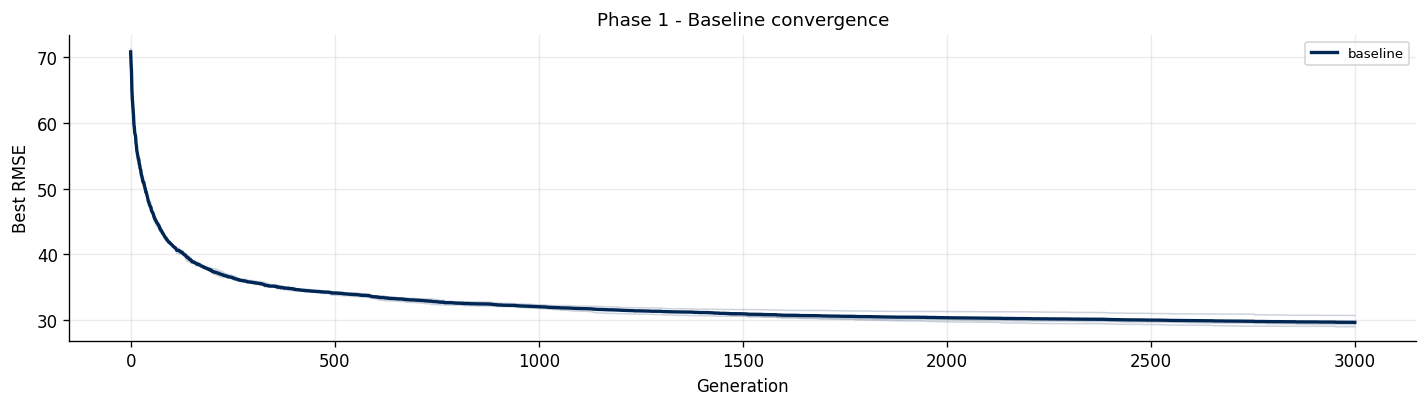

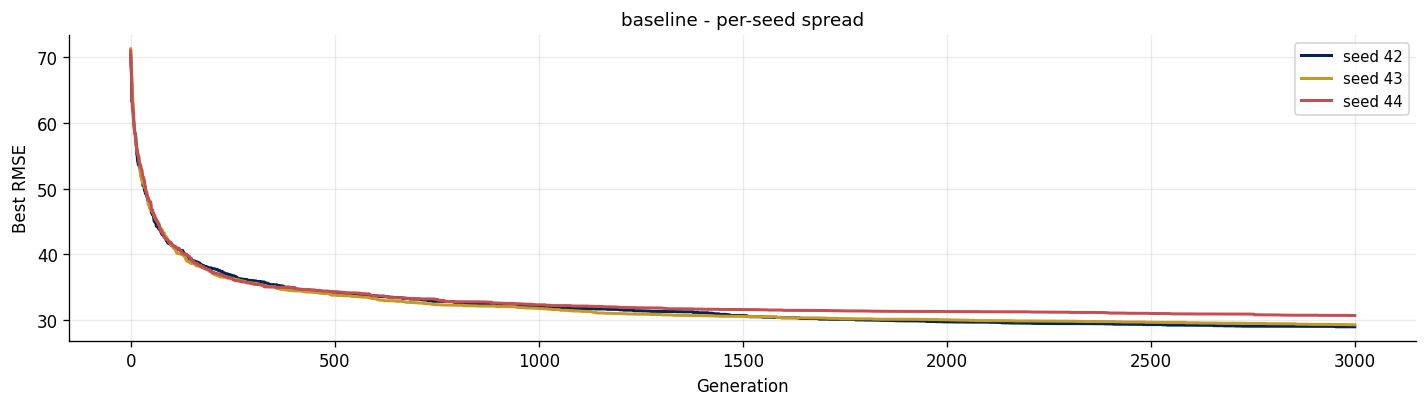

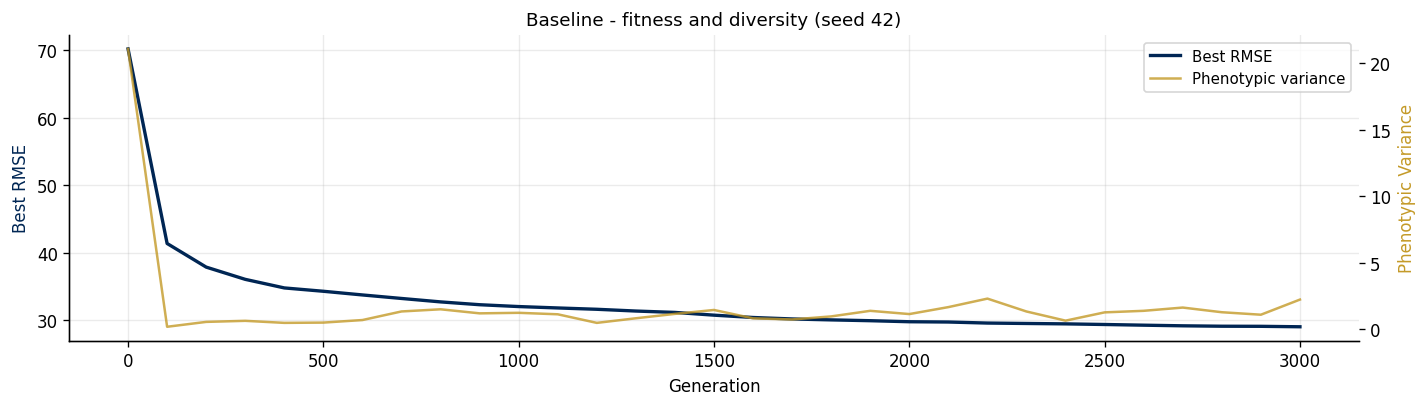

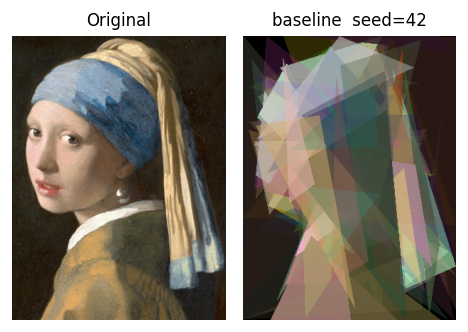

p1_baseline | mean=29.6871  std=0.7462  best=29.0168  worst=30.7280  n_seeds=3


In [13]:
# convergence + seed spread for the baseline
plot_convergence(1, "Phase 1 - Baseline convergence")
plot_seed_spread(1, "p1_baseline")
# fitness + diversity over generations (seed 42)
plot_diversity("p1_baseline", seed=42, title="Baseline - fitness and diversity (seed 42)")
plot_final_image("p1_baseline", seed=42, figsize=(4, 3))
# summary stats for the baseline
fits = grouped.get((1, "p1_baseline"), [])
if fits:
    print(f"p1_baseline | mean={np.mean(fits):.4f}  std={np.std(fits):.4f}  best={np.min(fits):.4f}  worst={np.max(fits):.4f}  n_seeds={len(fits)}")

The baseline converges rapidly in the first 500 generations, dropping from a random initialisation RMSE above 70 to roughly 35, then slowing considerably. By generation 3 000 it plateaus with a mean final RMSE of 29.69 (std=0.75, best seed 29.02, worst 30.73). The three seeds track each other closely throughout, suggesting the baseline configuration is stable and not sensitive to initialisation. This consistency is a good sign: differences observed in later phases are more likely to reflect genuine operator effects rather than seed noise.

### 8.1.2. Phase 2 (Elitism Sweep) Results Analysis

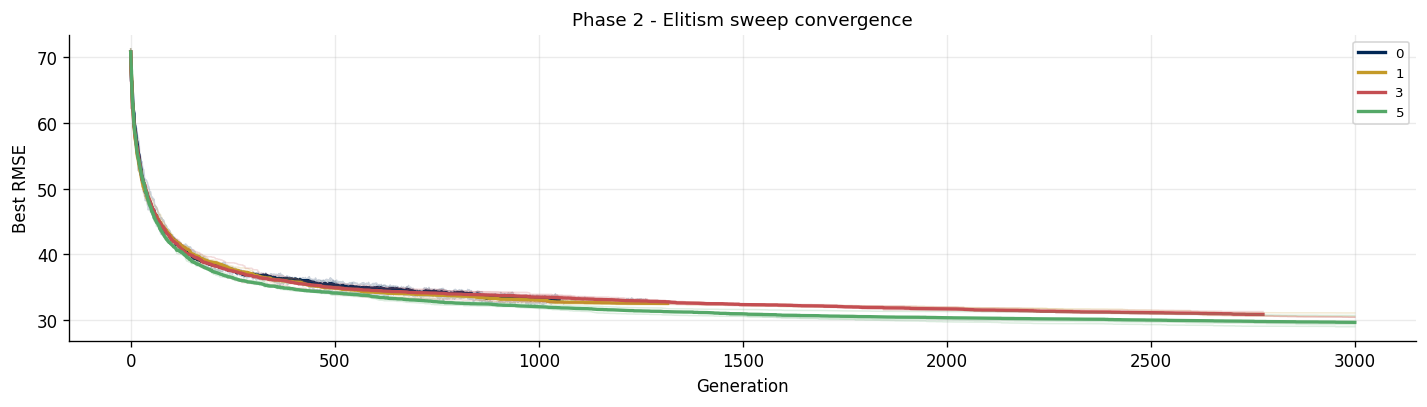

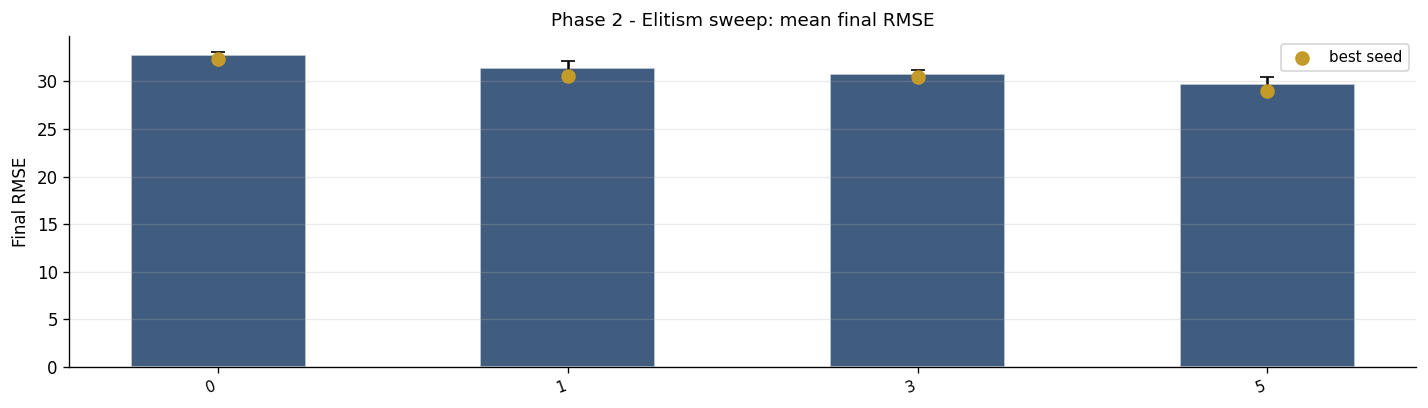


Config                                  Mean      Std     Best
--------------------------------------------------------------
5                                    29.6871   0.7462  29.0168
3                                    30.7541   0.4061  30.4577
1                                    31.3522   0.7557  30.5660
0                                    32.7169   0.3806  32.3198


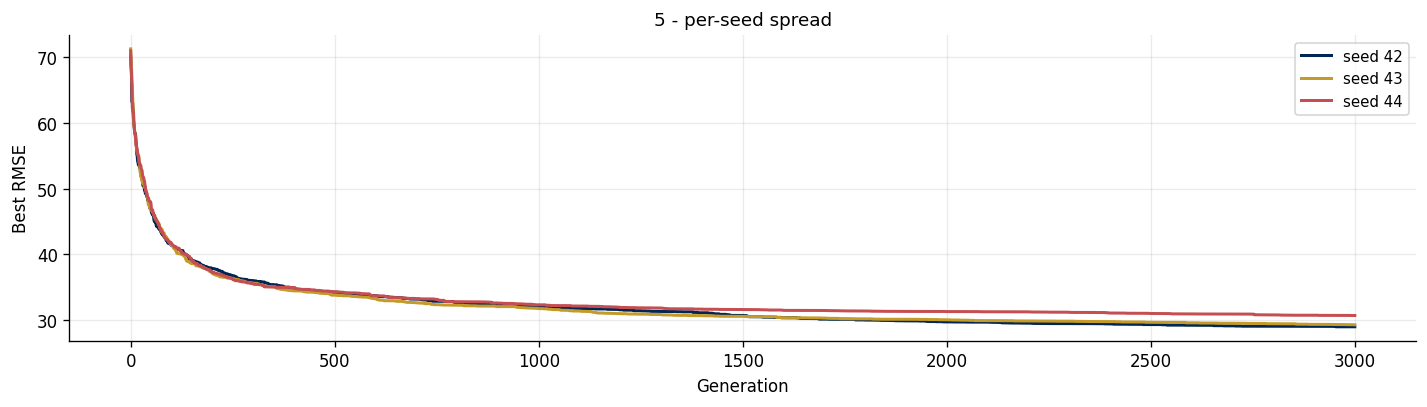

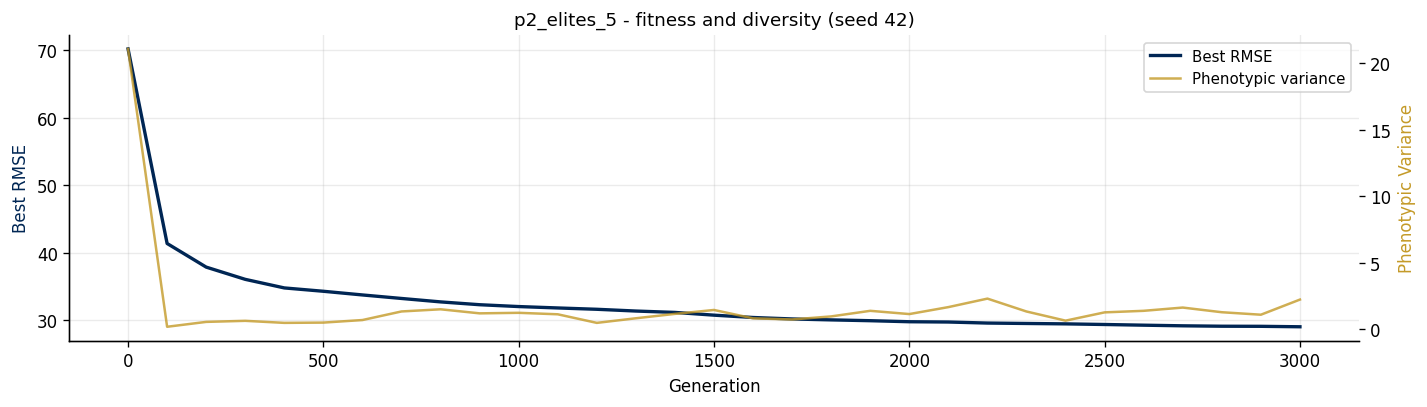

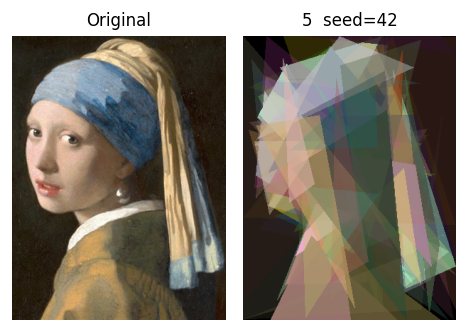

In [14]:
plot_convergence(2, "Phase 2 - Elitism sweep convergence")
plot_bar_summary(2, "Phase 2 - Elitism sweep: mean final RMSE")
# replace with best config after checking bar summary above
BEST_P2 = "p2_elites_5"

plot_seed_spread(2, BEST_P2)
plot_diversity(BEST_P2, seed=42, title=f"{BEST_P2} - fitness and diversity (seed 42)")
plot_final_image(BEST_P2, seed=42, figsize=(4, 3))

All elite counts converge to similar final RMSE values, with the spread between
configurations narrowing progressively after generation 1 000. The ranking is
monotone: more elites consistently yields better final fitness, with `n_elites=5`
(mean=29.69, std=0.75) outperforming `n_elites=0` (mean=32.72, std=0.38) by ~3
RMSE points. No-elitism (`n_elites=0`) is the clear outlier — it converges slower
in early generations and plateaus higher, confirming that preserving at least one
elite per generation is beneficial. The per-seed spread for `n_elites=5` is narrow
(seeds diverge by less than 1 RMSE at generation 3 000), and the diversity plot
shows phenotypic variance stabilising near zero after generation 100, indicating
the population converges quickly to a tight cluster. `n_elites=5` is carried
forward as the best configuration; the elitism question is revisited in Phase 8
with the full best operator set.

### 8.1.3. Phase 3 (Selection Sweep) Results Analysis

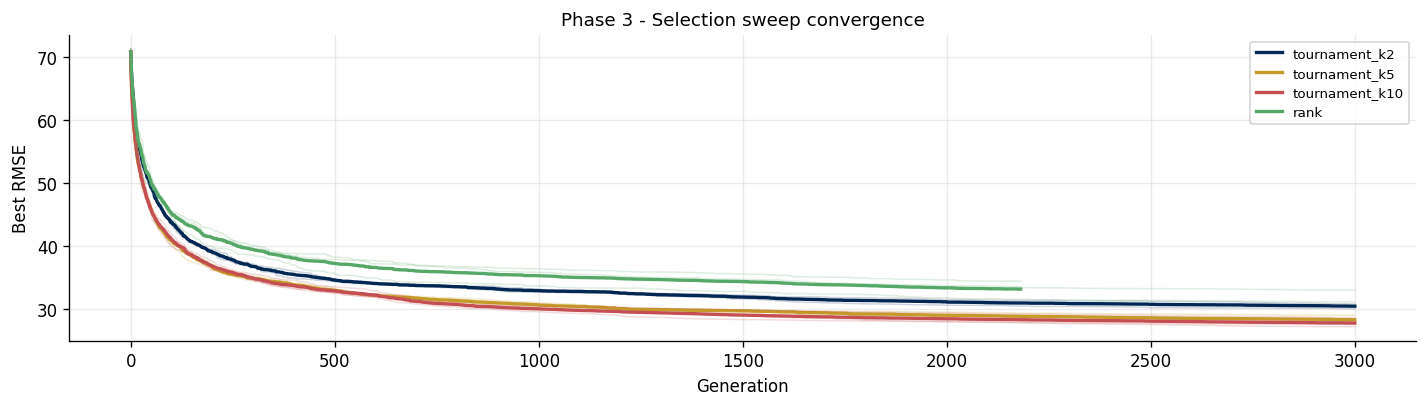

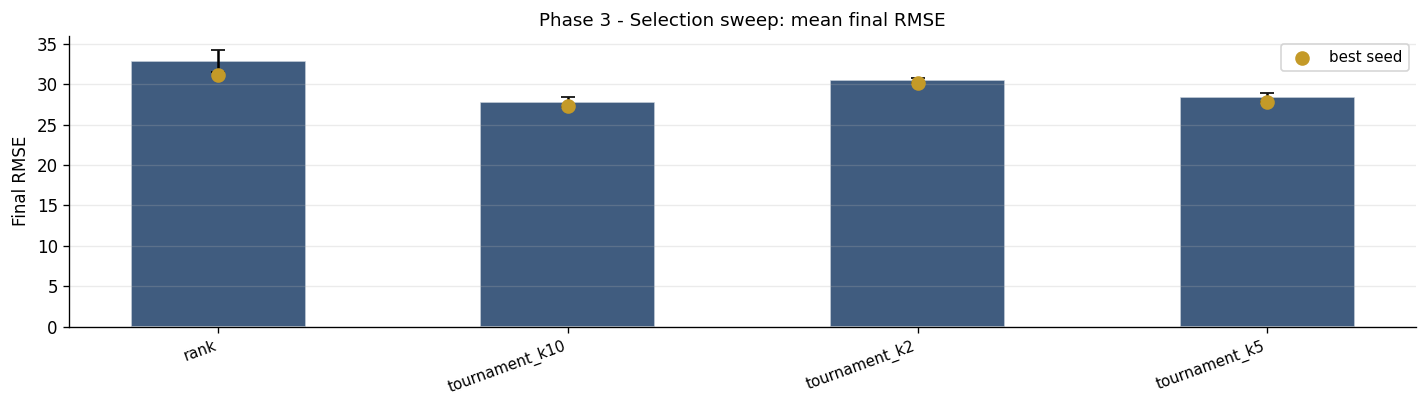


Config                                  Mean      Std     Best
--------------------------------------------------------------
tournament_k10                       27.8382   0.6196  27.2415
tournament_k5                        28.3515   0.5353  27.7683
tournament_k2                        30.4997   0.3042  30.0978
rank                                 32.8919   1.3466  31.1781


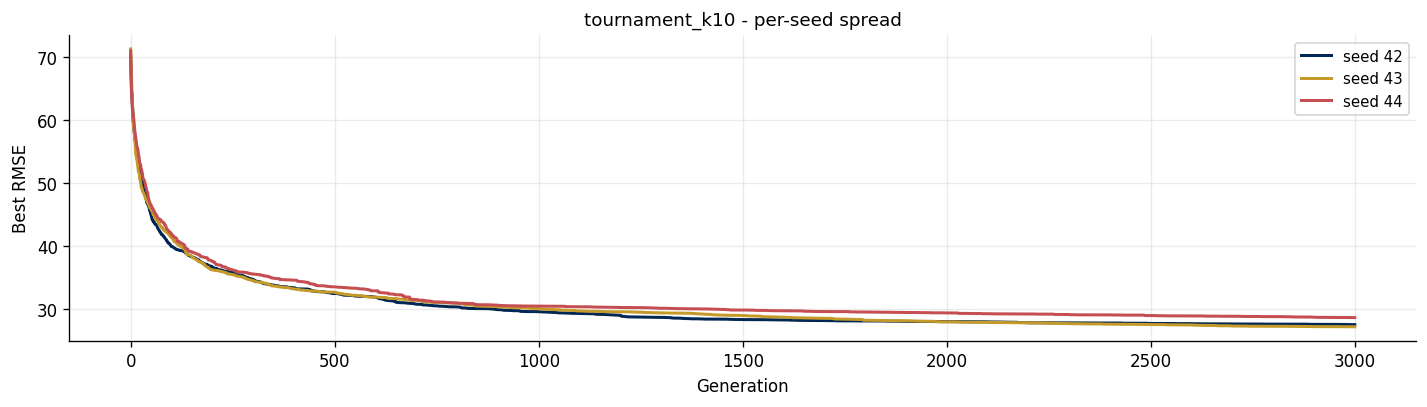

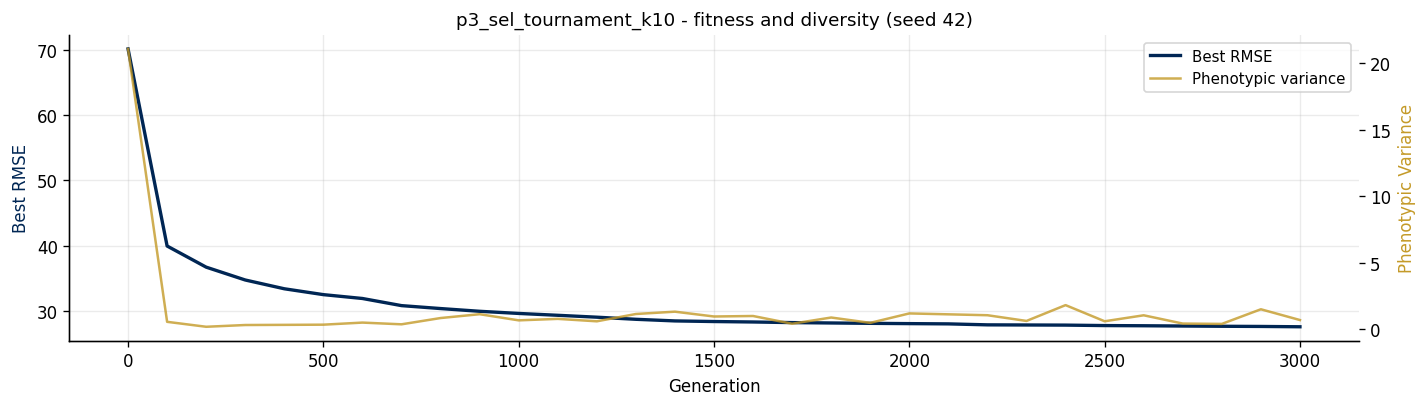

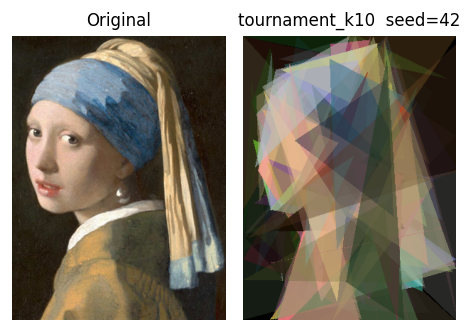

In [15]:
plot_convergence(3, "Phase 3 - Selection sweep convergence")
plot_bar_summary(3, "Phase 3 - Selection sweep: mean final RMSE")
# replace with best config after checking bar summary above
BEST_P3 = "p3_sel_tournament_k10"

plot_seed_spread(3, BEST_P3)
plot_diversity(BEST_P3, seed=42, title=f"{BEST_P3} - fitness and diversity (seed 42)")
plot_final_image(BEST_P3, seed=42, figsize=(4, 3))

`tournament_k10` achieves the best mean final RMSE (27.84, std=0.62), followed
closely by `tournament_k5` (28.35, std=0.54). The gap between these two and the
remaining operators is substantial: `tournament_k2` (30.50) and `RankSelection`
(32.89) lag behind by ~2.5 and ~5 RMSE points respectively. The convergence curves
make this separation clear — `rank` diverges visibly from the tournament variants
after generation 500 and never closes the gap, plateauing around 33-34 by
generation 3 000.

The result confirms the expected relationship between selection pressure and
convergence speed in this problem: higher tournament size drives faster and deeper
descent. `RankSelection` underperforms despite being a standard alternative,
likely because its linear ranking introduces less pressure than a large tournament
at this population size (N=50), where k=10 samples 20% of the population per
selection event.

The per-seed spread for `tournament_k10` is tight across all three seeds,
indicating the result is stable and not driven by a single lucky run.
`tournament_k10` is carried forward to Phase 4.

### 8.1.4. Phase 4 (Crossover Sweep) Results Analysis

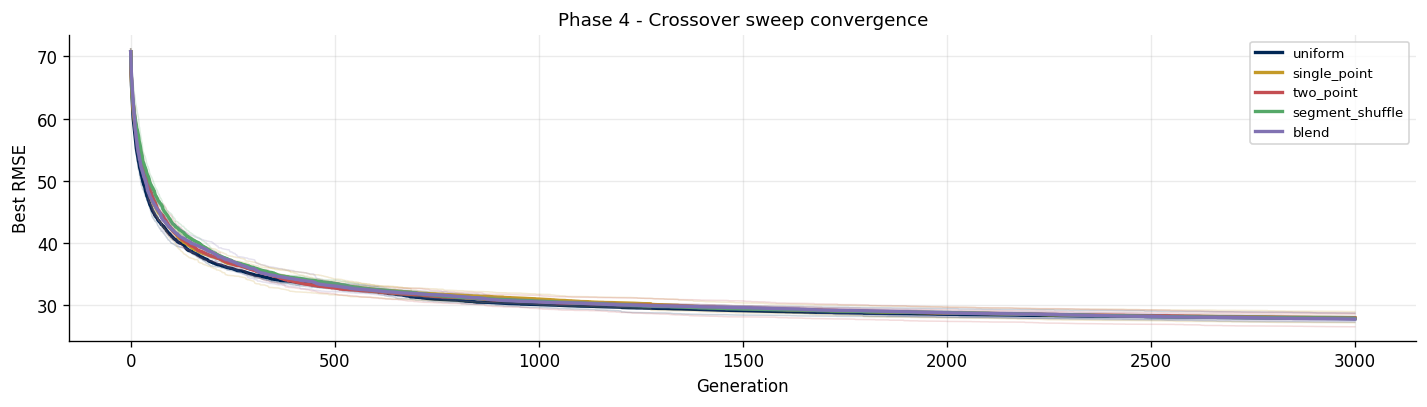

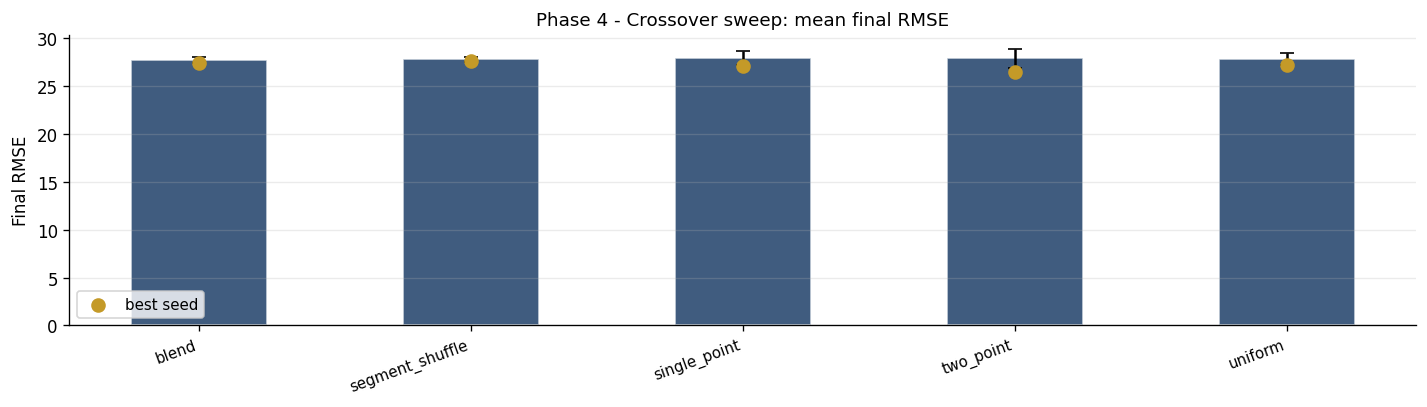


Config                                  Mean      Std     Best
--------------------------------------------------------------
blend                                27.7295   0.3045  27.4089
segment_shuffle                      27.8241   0.2491  27.6224
uniform                              27.8382   0.6196  27.2415
two_point                            27.9040   0.9957  26.4993
single_point                         27.9724   0.7390  27.1470


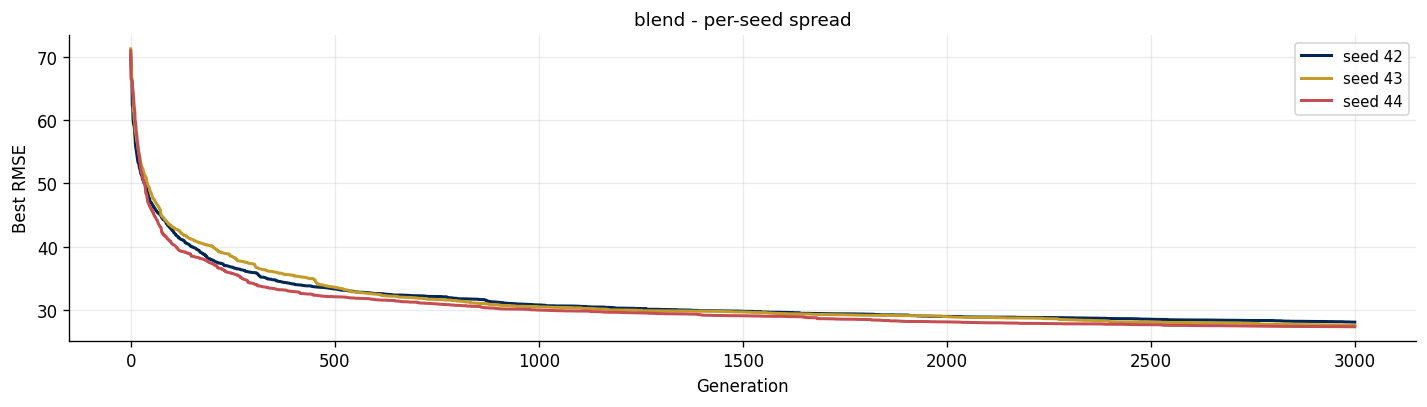

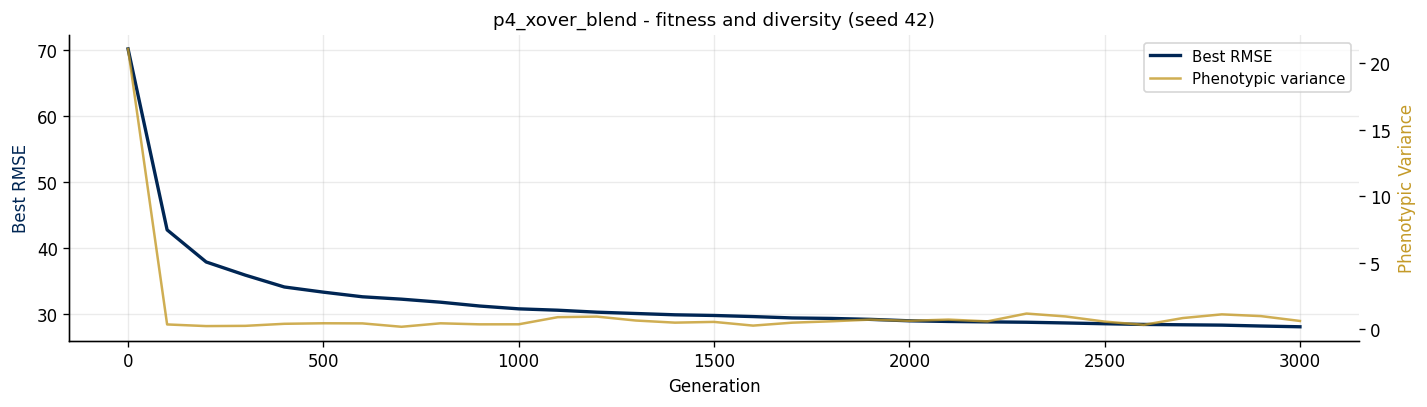

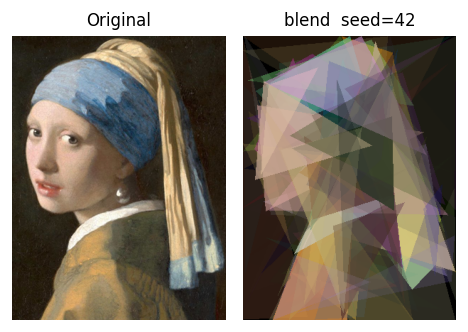

In [16]:
plot_convergence(4, "Phase 4 - Crossover sweep convergence")
plot_bar_summary(4, "Phase 4 - Crossover sweep: mean final RMSE")
# replace with best config after checking bar summary above
BEST_P4 = "p4_xover_blend"

plot_seed_spread(4, BEST_P4)
plot_diversity(BEST_P4, seed=42, title=f"{BEST_P4} - fitness and diversity (seed 42)")
plot_final_image(BEST_P4, seed=42, figsize=(4, 3))

All five crossover operators converge to nearly identical final RMSE values,
with means ranging from 27.73 (`blend`) to 27.97 (`single_point`) — a spread of
less than 0.25 RMSE across the entire phase. The convergence curves confirm this:
all five operators are indistinguishable after generation 1 000, and the per-seed
thin lines for each config overlap almost completely. This suggests that at this
stage of the search, with `tournament_k10` driving strong selection pressure, the
crossover operator has minimal influence on final fitness — the bottleneck lies
elsewhere.

Despite the near-identical means, `blend` has the lowest mean (27.73) and the
tightest std (0.30), while `two_point` shows the highest variance (std=1.00) with
the best individual seed (26.50) — indicating that `two_point` is less consistent
but occasionally produces better solutions. `blend` is carried forward for its
stability; note however that given the small differences any of the five operators
would be a defensible choice at this phase.

### 8.1.5. Phase 5 (Mutation Sweep) Results Analysis

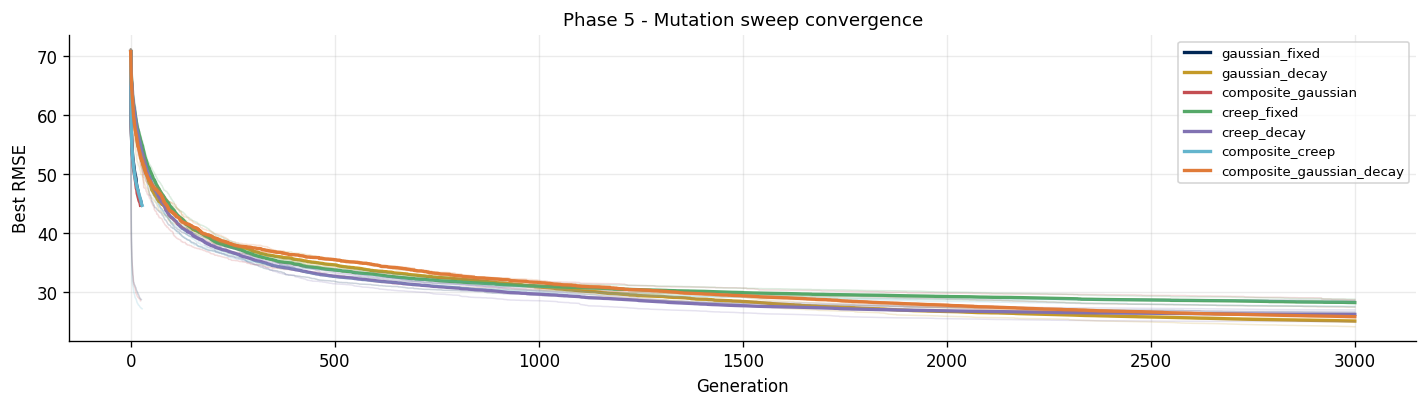

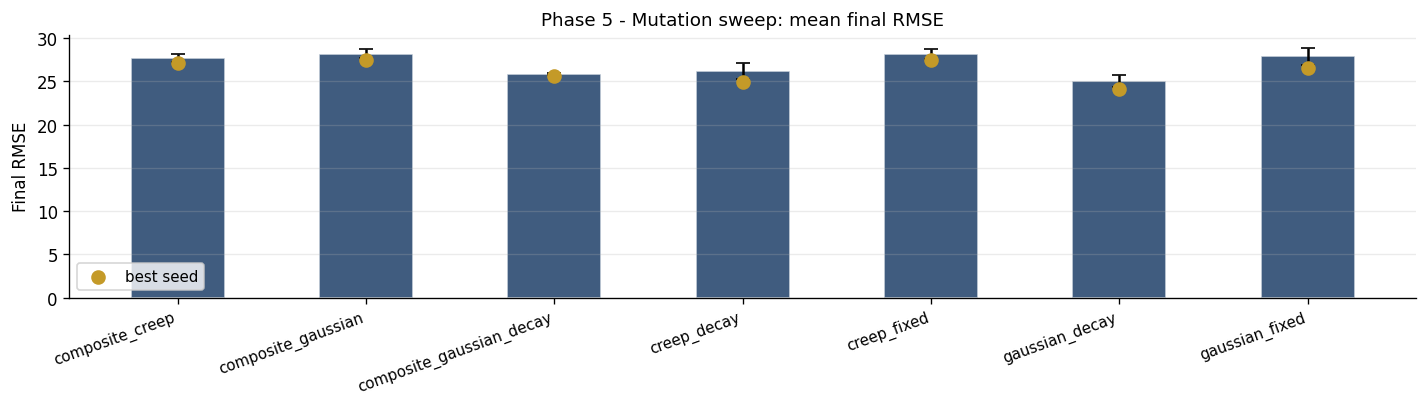


Config                                  Mean      Std     Best
--------------------------------------------------------------
gaussian_decay                       25.0458   0.7030  24.0818
composite_gaussian_decay             25.7932   0.1190  25.6309
creep_decay                          26.1783   0.8889  24.9325
composite_creep                      27.6440   0.4537  27.1341
gaussian_fixed                       27.9040   0.9957  26.4993
creep_fixed                          28.1863   0.5727  27.4068
composite_gaussian                   28.1903   0.5386  27.4333


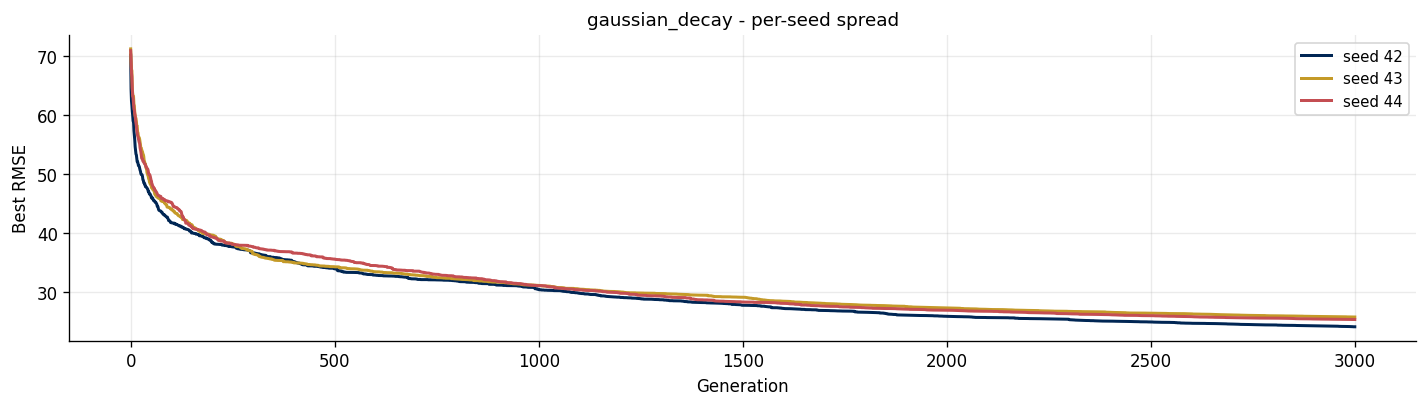

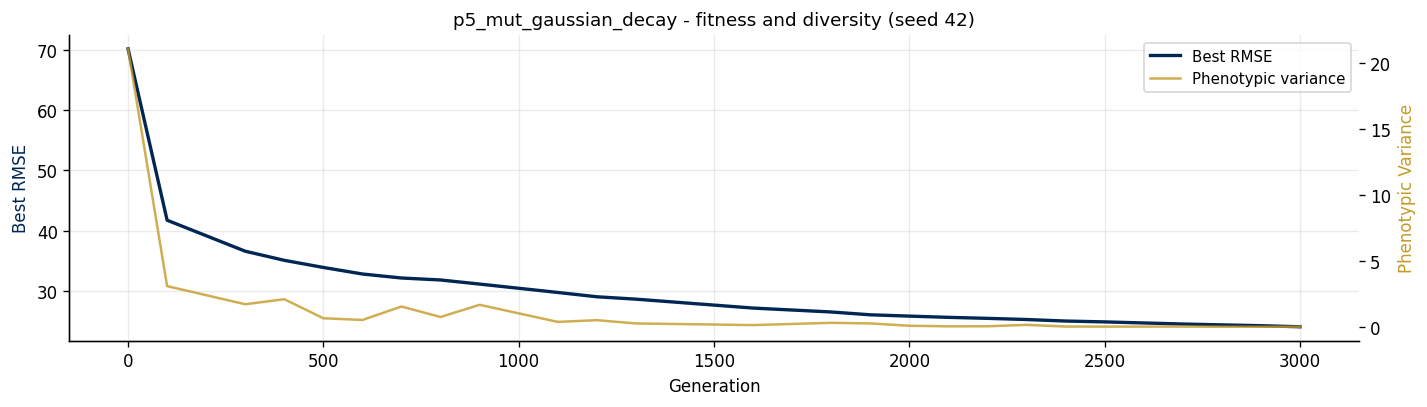

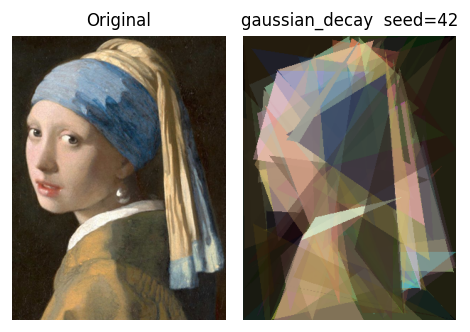

In [17]:
plot_convergence(5, "Phase 5 - Mutation sweep convergence")
plot_bar_summary(5, "Phase 5 - Mutation sweep: mean final RMSE")

# replace with best config after checking bar summary above
BEST_P5 = "p5_mut_gaussian_decay"

plot_seed_spread(5, BEST_P5)
plot_diversity(BEST_P5, seed=42, title=f"{BEST_P5} - fitness and diversity (seed 42)")
plot_final_image(BEST_P5, seed=42, figsize=(4, 3))

Phase 5 shows the largest performance spread of any OFAT phase: `gaussian_decay` achieves the best mean RMSE (25.05, std=0.70), while the worst performers (`creep_fixed`, `composite_gaussian`) sit around 28.19 — a gap of over 3 RMSE points. The two clear conclusions from the data are:

**Decay beats fixed sigma.** Both `gaussian_decay` (25.05) and `creep_decay` (26.18) outperform their fixed-sigma counterparts `gaussian_fixed` (27.90) and `creep_fixed` (28.19) by ~2-3 RMSE points. The decay schedule maintains large perturbations early for exploration and tightens them progressively, allowing the search to refine solutions as the population converges — a pattern confirmed by the diversity plot, where phenotypic variance drops rapidly after generation 100 and tracks the fitness curve closely through to generation 3 000.

**Gaussian beats creep.** Within both the fixed and decay families, Gaussian perturbation consistently outperforms creep. This is likely because Gaussian noise can produce both small and large perturbations from the same distribution, whereas creep is bounded by a fixed delta, limiting its reach in early generations.

**Composite operators do not help.** `composite_gaussian_decay` (25.79) comes close to `gaussian_decay` but adds `ResetMutation` and `SwapMutation` on top — the added structural perturbations introduce disruption that the selection pressure cannot fully overcome at this population size, yielding higher variance and worse mean. `composite_creep` (27.64) and `composite_gaussian` (28.19) reinforce this: the composite strategy adds complexity without benefit here.

`gaussian_decay` is carried forward as the best mutation operator, with a mean improvement of ~2.8 RMSE over the `gaussian_fixed` baseline used in Phases 1-4.

## 8.2. Post-OFAT Refinement Phases Result 

### 8.2.1. Phase 6: the effect of more generations

Best configuration from Phases 3-5 (`tournament_k10`, `two_point`, `gaussian_decay`, 5 elites) extended to 20 000 generations, population 50. Single config, 3 seeds.

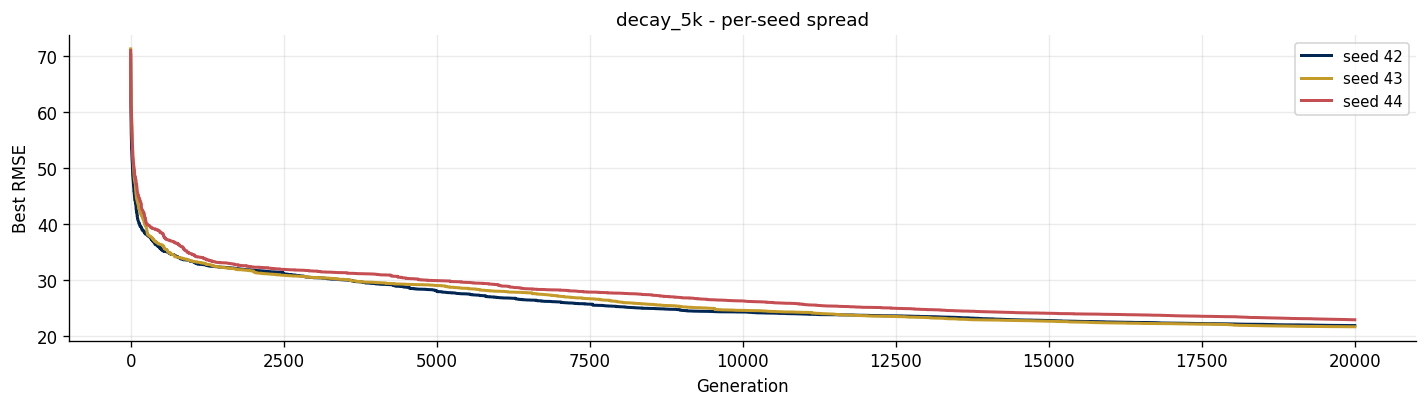

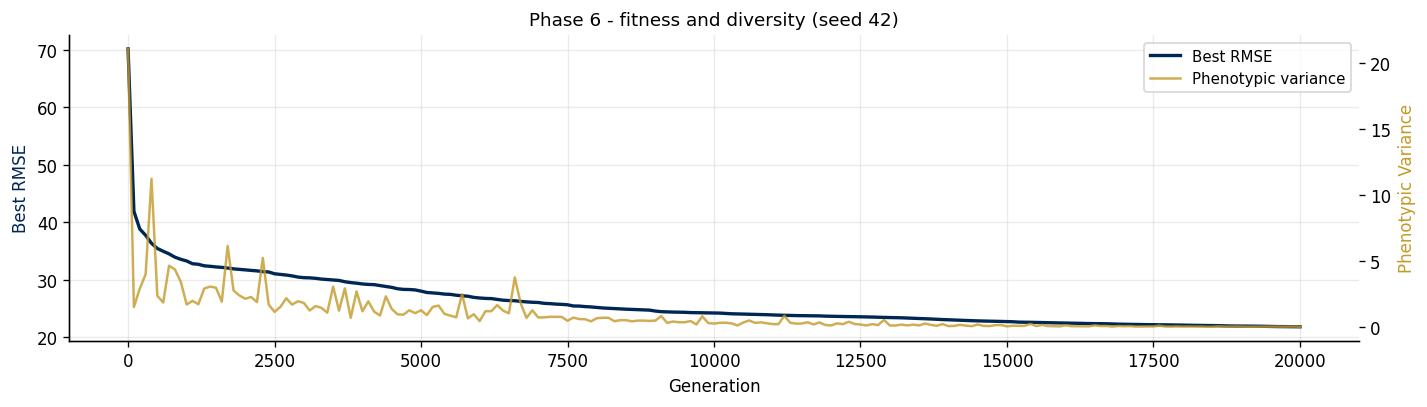


Config                                  Mean      Std     Best    Worst
----------------------------------------------------------------------
p6_gaussian_decay_5k                 22.2470   0.6267  21.6204  22.8737


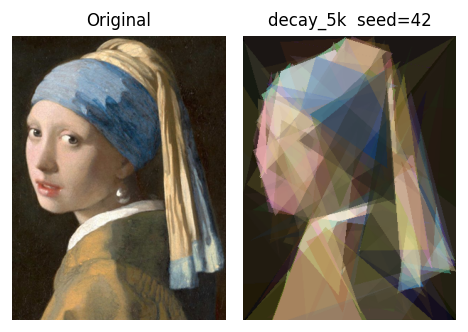

In [34]:
plot_seed_spread(6, "p6_gaussian_decay_5k")
plot_diversity("p6_gaussian_decay_5k", seed=42, title="Phase 6 - fitness and diversity (seed 42)")
fits = grouped.get((6, "p6_gaussian_decay_5k"), [])
if fits:
    print(f"\n{'Config':<35} {'Mean':>8} {'Std':>8} {'Best':>8} {'Worst':>8}")
    print("-" * 70)
    print(f"{'p6_gaussian_decay_5k':<35} {np.mean(fits):>8.4f} {np.std(fits):>8.4f} {np.min(fits):>8.4f} {np.max(fits):>8.4f}")
plot_final_image("p6_gaussian_decay_5k", seed=42, figsize=(4, 3))


Extending the best OFAT configuration (`tournament_k10`, `two_point`,
`gaussian_decay`, 5 elites) from 3 000 to 20 000 generations yields a clear
improvement: mean RMSE drops from 25.05 (Phase 5) to 22.25 — a reduction of ~2.8
RMSE points under identical operators. The three seeds remain consistent
(std=0.63), confirming the improvement is not driven by a single lucky run.

The convergence curve shows no plateau at generation 3 000 — the search continues
descending steadily well past that point, only flattening after ~15 000 generations
as diversity approaches zero. The diversity plot corroborates this: phenotypic
variance oscillates in bursts through the first 10 000 generations, suggesting the
mutation decay is still supplying enough perturbation to escape local optima before
eventually collapsing near generation 18 000. This confirms that the 3 000-generation
budget used in Phases 1-5 was a binding constraint, and that the operator
configuration has not yet exhausted its potential — motivating the extended budgets
in the final phases.

### 8.2.2. Phase 7 - Initialisation Strategy Sweep

Tests 6 initialisation strategies (`random`, `semi_transparent`, `small_random`, `grid_random_color`, `sorted_alpha`, `quadrant`) with all operators fixed at best from Phases 3-5. All configs ran for 500 generations (screening budget).  
Population 50, seed 42 only.

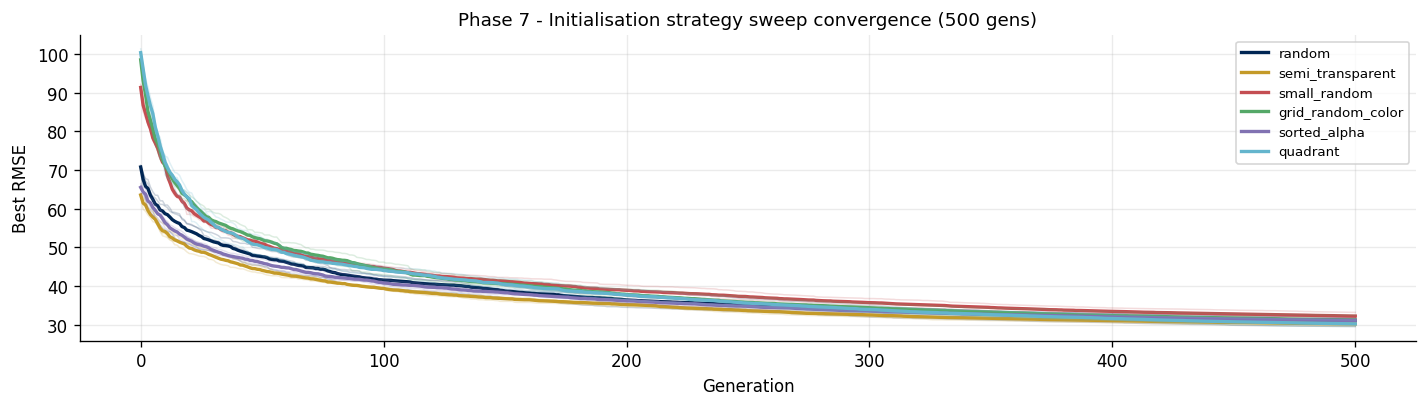

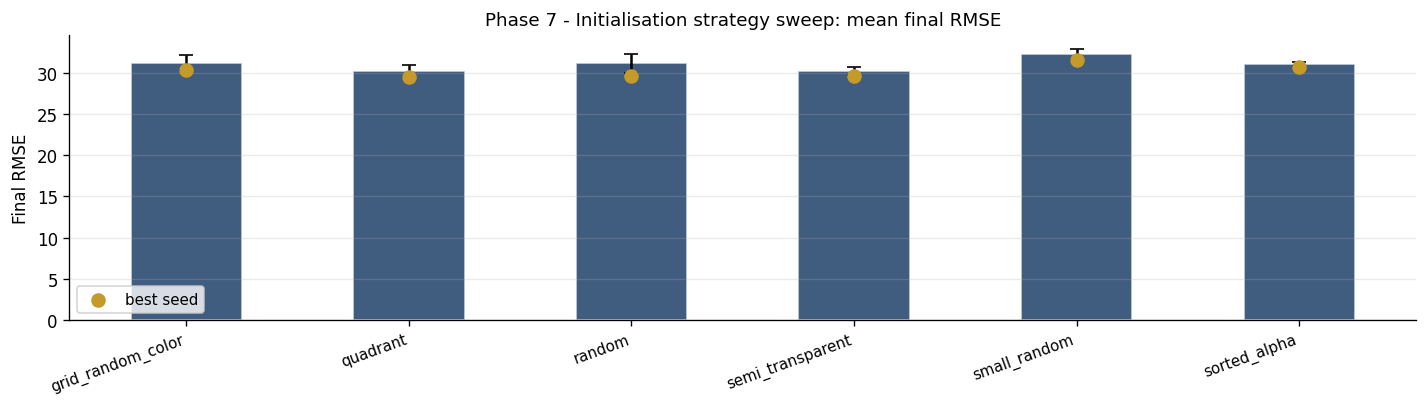


Config                                  Mean      Std     Best
--------------------------------------------------------------
quadrant                             30.2495   0.7098  29.5015
semi_transparent                     30.2527   0.4731  29.6369
sorted_alpha                         31.1287   0.2613  30.7832
random                               31.1513   1.1015  29.5938
grid_random_color                    31.2528   0.9075  30.3514
small_random                         32.2644   0.6995  31.5768


In [19]:
plot_convergence(7, "Phase 7 - Initialisation strategy sweep convergence (500 gens)")
plot_bar_summary(7, "Phase 7 - Initialisation strategy sweep: mean final RMSE")

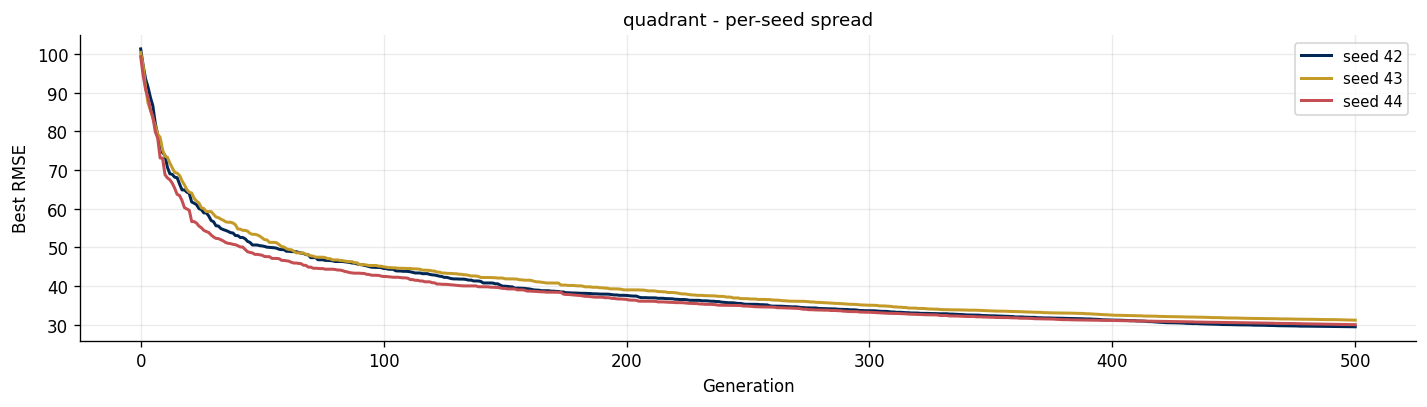

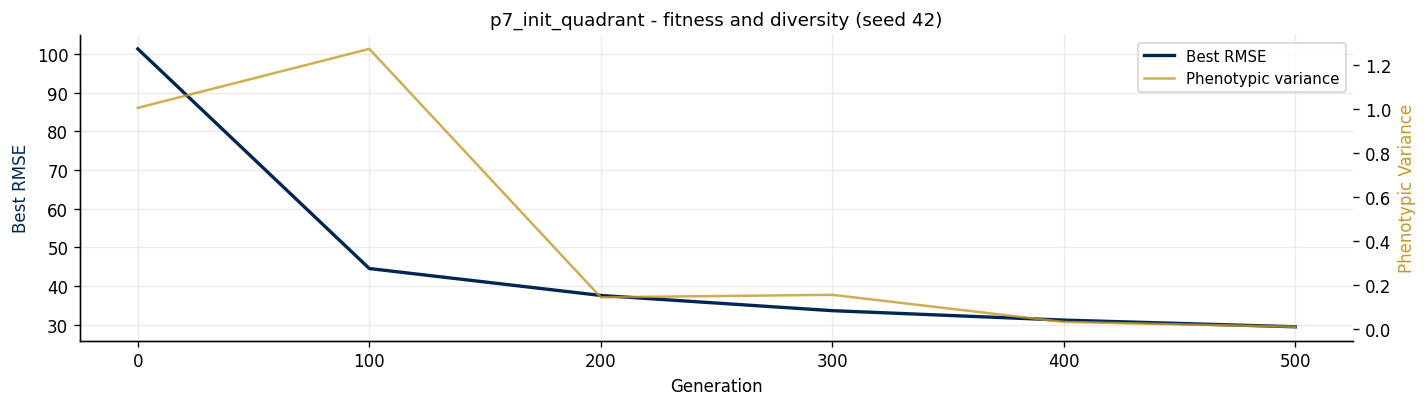

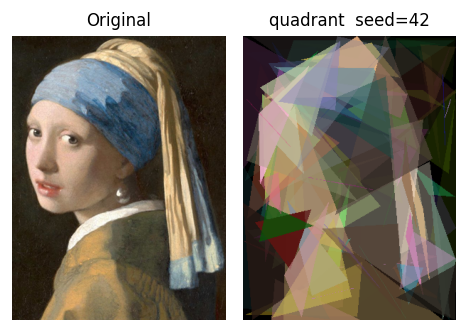

In [20]:
BEST_P7 = "p7_init_quadrant"

plot_seed_spread(7, BEST_P7)
plot_diversity(BEST_P7, seed=42, title=f"{BEST_P7} - fitness and diversity (seed 42)")
plot_final_image(BEST_P7, seed=42, figsize=(4, 3))

At 500 generations all six strategies converge to similar RMSE values, ranging
from 30.25 (`quadrant`) to 32.26 (`small_random`) — a spread of ~2 RMSE points.
The convergence curves confirm this: all strategies start from different initial
RMSE values but the gaps close rapidly within the first 100 generations, with
`tournament_k10` selection quickly correcting poor starting points.

`quadrant` and `semi_transparent` tie at the top (30.25 and 30.25 respectively),
with `quadrant` having slightly higher variance (std=0.71 vs 0.47). `small_random`
is the clear underperformer — very small triangles provide poor initial coverage
and the 500-generation budget is insufficient to compensate. `random` has the
highest variance (std=1.10), reflecting its sensitivity to initialisation luck.

The diversity plot for `quadrant` is worth noting: it only has 6 data points (one
per 100-generation checkpoint) given the short budget, but shows diversity
collapsing sharply between generation 100 and 200 — the structured initialisation
gives the population a head start but the search converges fast. `quadrant` is
carried forward for its best mean and for providing a spatially structured start
that distributes triangles across the canvas from generation 0.

#### 8.2.2.1 Quadrant Initialisation - Full Run (3 000 generations)

`quadrant` was identified as the best initialisation strategy and re-run at the full 3000 generation budget to assess its ceiling performance before carrying it forward.

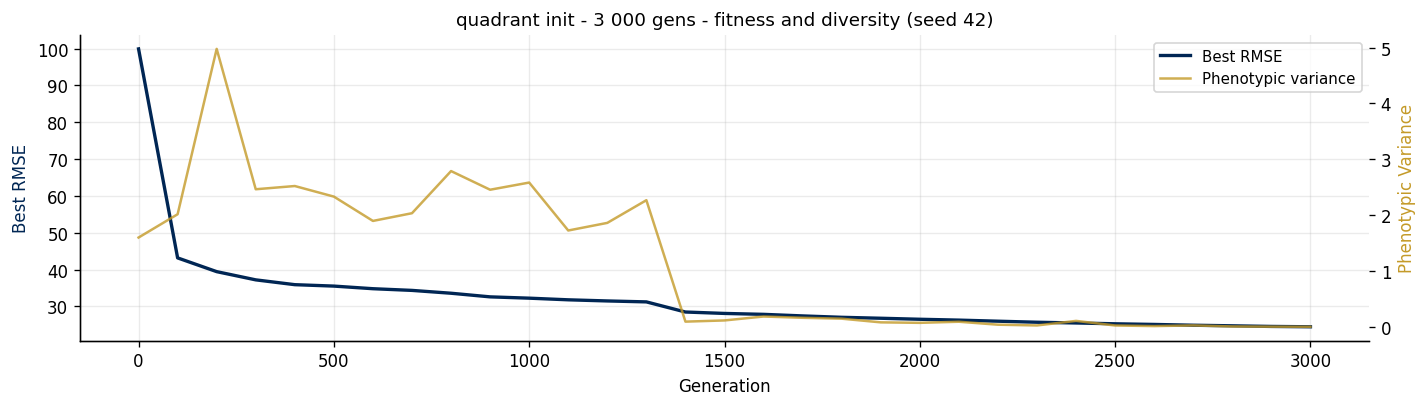

final RMSE (seed 42): 24.4569


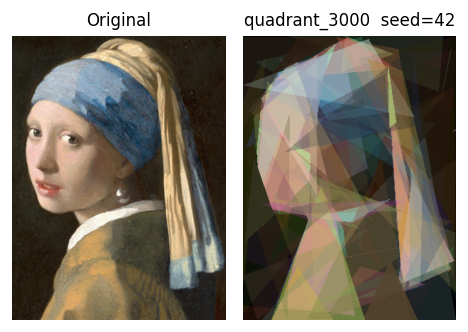

In [41]:
quadrant_3k_rows = [
    r for r in rows
    if r["run_name"] == "p7_init_quadrant_3000"
]
for r in quadrant_3k_rows:
    print(f"  seed={r['seed']}  fitness={r['final_best_fitness']}  gens={r['n_generations_run']}")

plot_diversity("p7_init_quadrant_3000", seed=42, title="quadrant init - 3 000 gens - fitness and diversity (seed 42)")
log = load_generation_log("p7_init_quadrant_3000", seed=42)
if log:
    final = log[-1]["best"]
    print(f"final RMSE (seed 42): {final:.4f}")
plot_final_image("p7_init_quadrant_3000", seed=42, figsize=(4, 3))

`quadrant` was identified as the best initialisation strategy at the 500-generation
screening budget (mean RMSE 30.25, 3 seeds). To assess whether this advantage
persists with a full budget, it was re-run for 3 000 generations with a single
seed. The result confirms the benefit: final RMSE drops to 24.46 — an improvement
of ~5.8 RMSE points over the 500-generation result, and on par with the best
Phase 5 result (25.05), using the same operator set (`tournament_k10`, `two_point`,
`gaussian_decay`, 5 elites). `quadrant` is carried forward as the initialisation
strategy for all remaining phases.

### 8.2.3. Phase 8 - Elitism Re-test

Re-tests `n_elites` in {1, 3, 7, 10} with all operators now fixed at best values from Phases 3-5 (`tournament_k10`, `blend`, `gaussian_decay`). `n_elites=5` is not re-run here as it serves as the carry-over reference from Phase 2. 

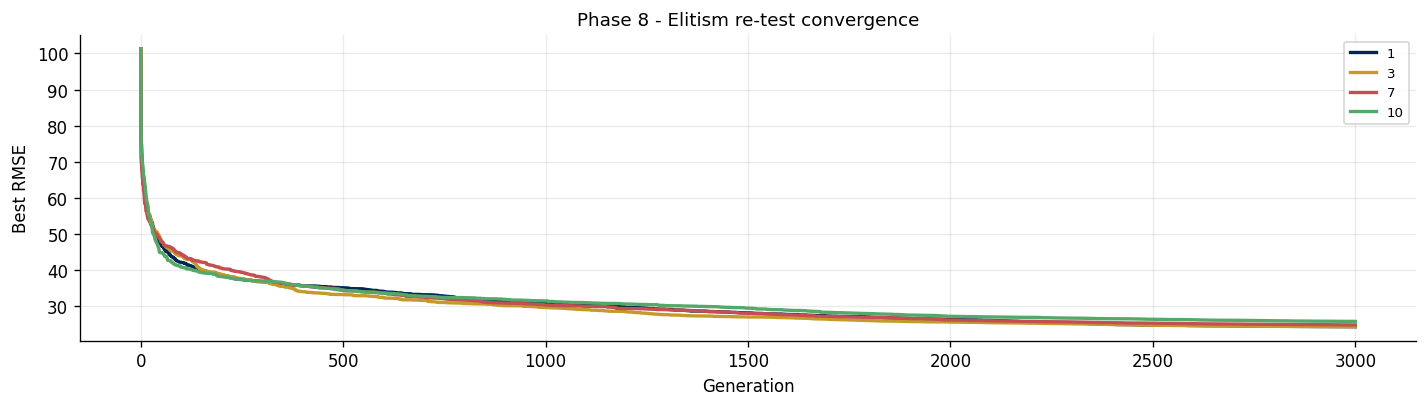

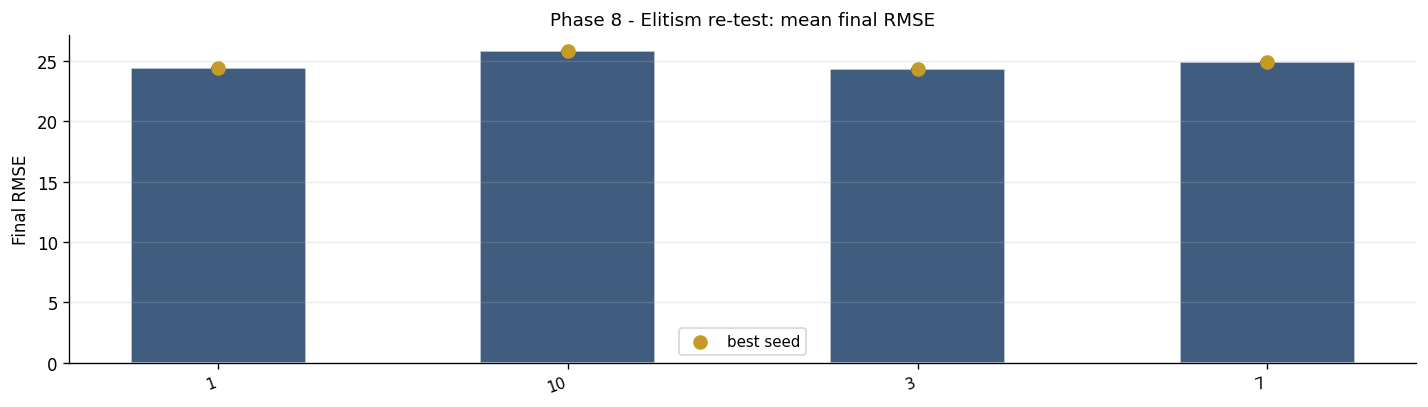


Config                                  Mean      Std     Best
--------------------------------------------------------------
3                                    24.3529   0.0000  24.3529
1                                    24.3799   0.0000  24.3799
7                                    24.8599   0.0000  24.8599
10                                   25.8370   0.0000  25.8370


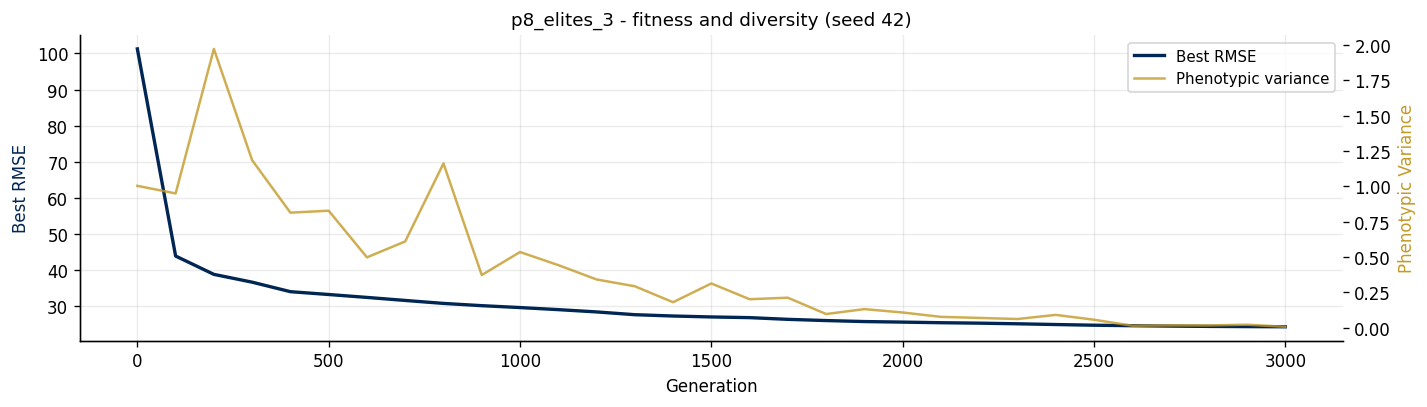

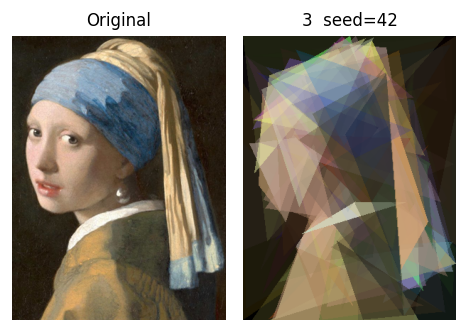

In [42]:
plot_convergence(8, "Phase 8 - Elitism re-test convergence")
plot_bar_summary(8, "Phase 8 - Elitism re-test: mean final RMSE")

BEST_P8 = "p8_elites_3"

plot_diversity(BEST_P8, seed=42, title=f"{BEST_P8} - fitness and diversity (seed 42)")
plot_final_image(BEST_P8, seed=42, figsize=(4, 3))

> **Note:** due to the computational cost of running the full operator set at this
> stage, each configuration was evaluated with a single seed only. Results should
> be interpreted with caution — the observed ranking may not be fully robust to
> seed variation, though the directional finding (lower elitism performs better
> with high selection pressure) is consistent with theoretical expectations.

Re-testing elitism with the full best operator set (`tournament_k10`, `blend`,
`gaussian_decay`) reverses the Phase 2 finding. Lower elite counts now perform
better: `n_elites=3` achieves the best mean RMSE (24.35), followed by `n_elites=1`
(24.38), while `n_elites=7` (24.86) and `n_elites=10` (25.84) stay behind. The
gap between the top and bottom is ~1.5 RMSE points — small but consistent.

This reversal is explained by the interaction between selection pressure and
elitism. With `tournament_k10` already sampling 20% of the population per
selection event, the top individuals are heavily favoured in reproduction. A large
elite pool adds redundancy on top of this: too many identical or near-identical
individuals are copied each generation, reducing the effective offspring
pool and slowing exploration. With `n_elites=3`, the best solutions are preserved
without dominating the next generation.

The diversity plot for `n_elites=3` shows phenotypic variance remaining active
through generation ~1 000 before gradually declining — consistent with a
configuration that preserves exploration longer than high-elitism alternatives.
`n_elites=3` is carried forward.

### 8.2.4. Phase 9 - Interaction Check: Selection x Mutation

Tests whether `tournament_k5` paired with `blend` + `gaussian_decay` or `creep_decay` can outperform the `tournament_k10` winner from Phase 3. `n_elites=3` (best from Phase 8).  
3 seeds x 3 000 generations, population 50.

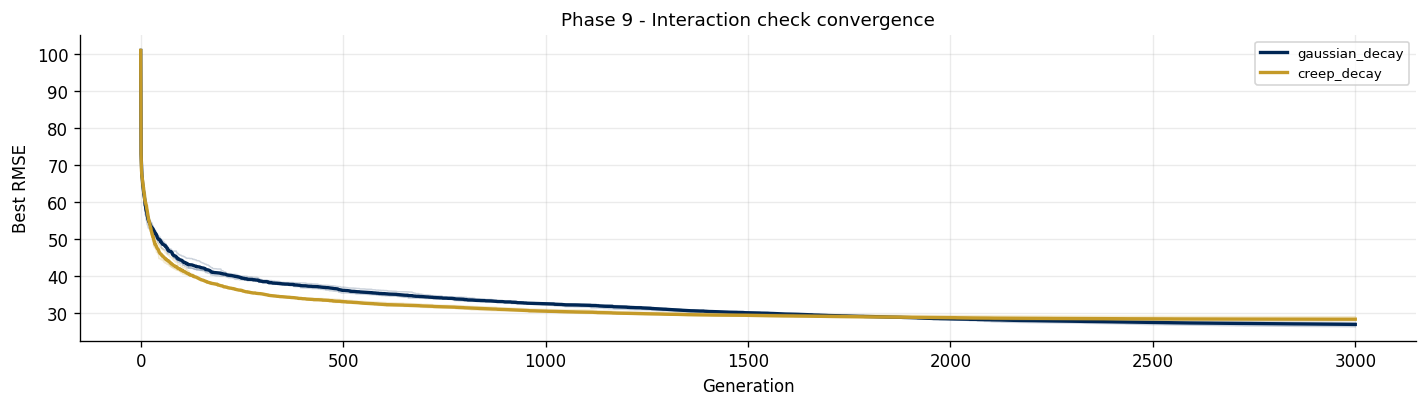

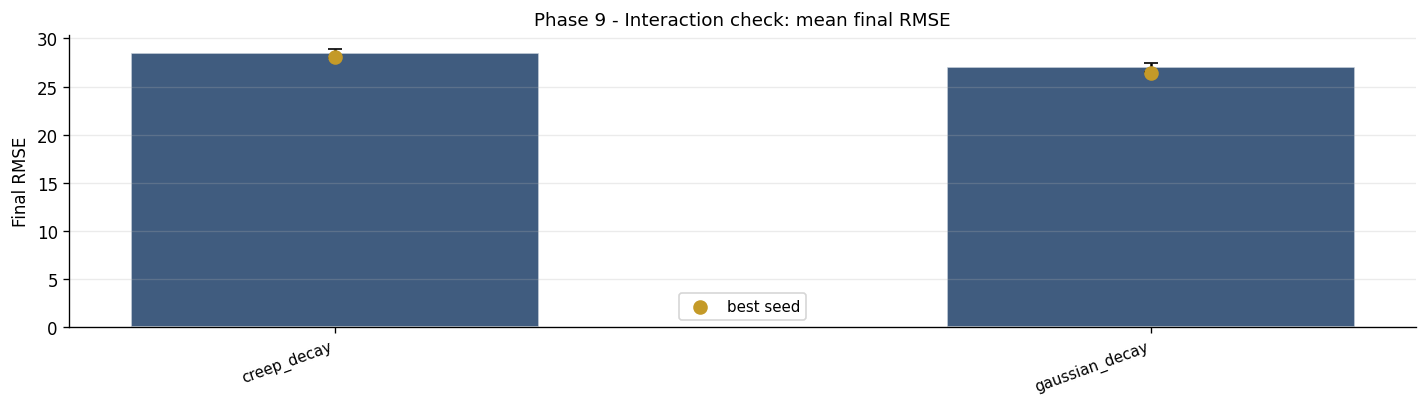


Config                                  Mean      Std     Best
--------------------------------------------------------------
gaussian_decay                       27.0280   0.4699  26.3966
creep_decay                          28.4425   0.4690  28.0305


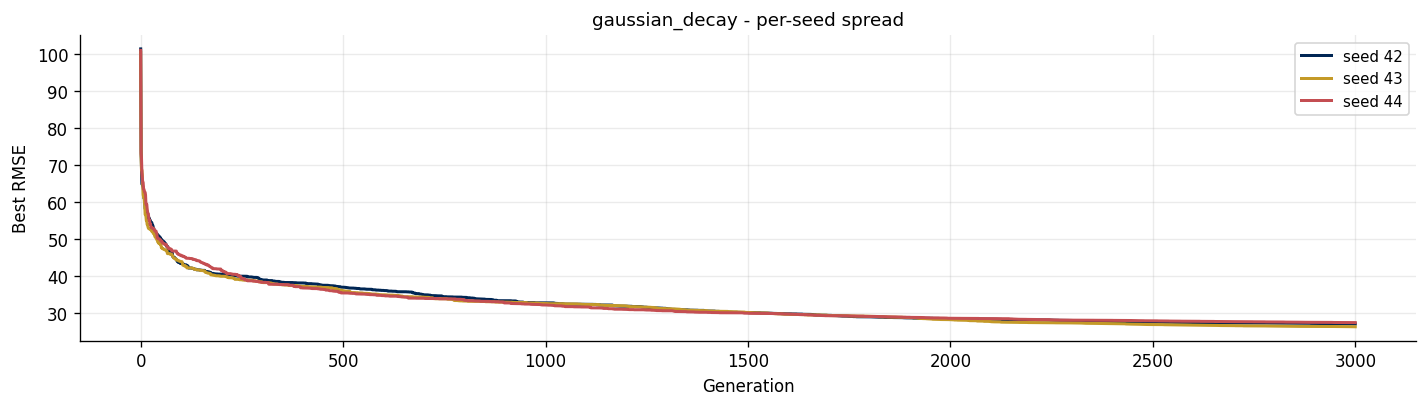

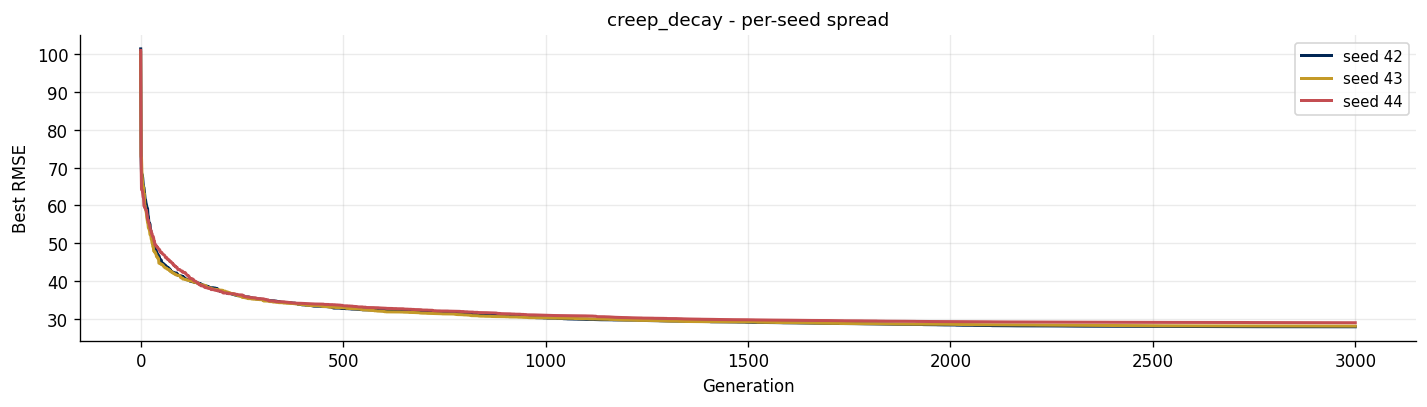

In [23]:
plot_convergence(9, "Phase 9 - Interaction check convergence")
plot_bar_summary(9, "Phase 9 - Interaction check: mean final RMSE")

# compare seed spread for both configs side by side
plot_seed_spread(9, "p9_k5_gaussian_decay")
plot_seed_spread(9, "p9_k5_creep_decay")

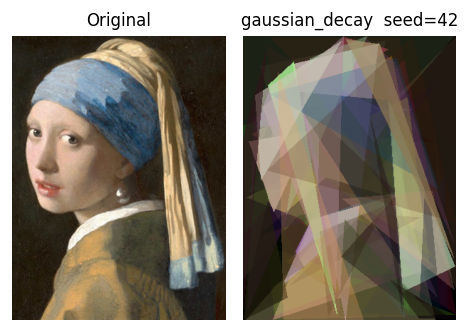

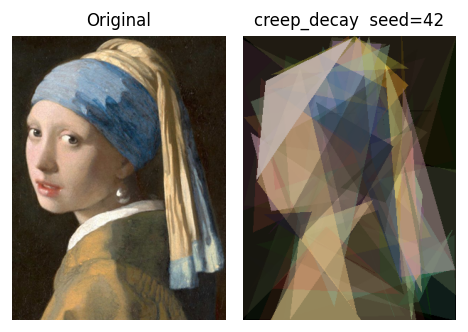

In [43]:
plot_final_image("p9_k5_gaussian_decay", seed=42, figsize=(4, 3))
plot_final_image("p9_k5_creep_decay", seed=42, figsize=(4, 3))

Neither `tournament_k5` variant outperforms the `tournament_k10` winner from
Phase 3. `tournament_k5` + `gaussian_decay` achieves a mean RMSE of 27.03,
and `tournament_k5` + `creep_decay` 28.44 — both worse than the Phase 5
`tournament_k10` + `gaussian_decay` result (25.05). The convergence curves
are nearly indistinguishable between the two configs and the per-seed spread
for `gaussian_decay` is tight (std=0.47), confirming the result is stable.

The interaction check therefore does not overturn the Phase 3 finding:
`tournament_k10` remains the better selection operator regardless of which
mutation is paired with it. `tournament_k10` + `gaussian_decay` is carried
forward as the confirmed selection-mutation combination.

### 8.2.5. Phase 10 - Grid Search: mutation_rate x vertex_sigma_max

Tests the interaction between perturbation frequency (`mutation_rate`) and magnitude (`vertex_sigma_max`).  11 combinations (4 rates x 3 sigma values, minus one duplicate from baseline). 

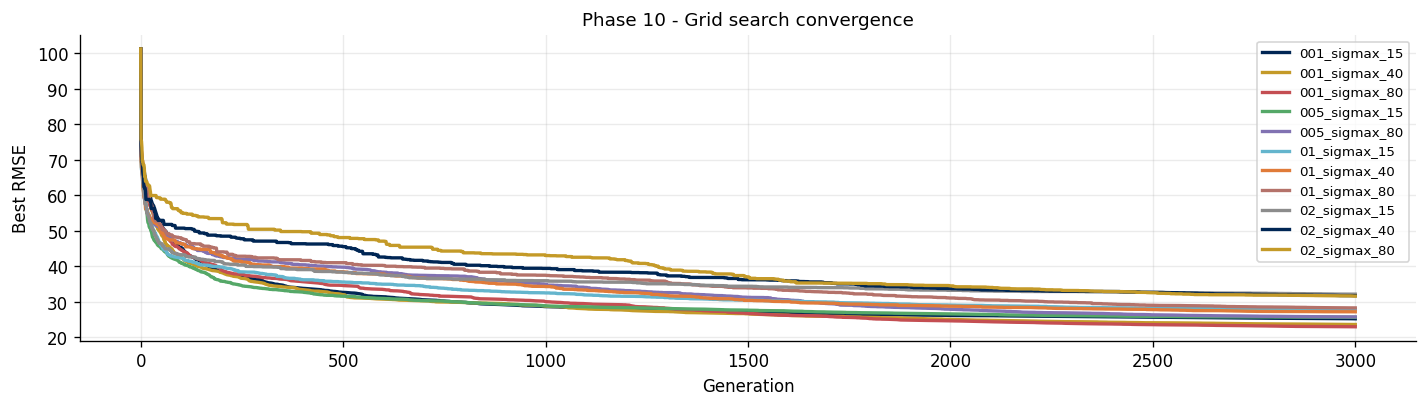


Config                        RMSE
-----------------------------------
001_sigmax_80              22.9914
001_sigmax_40              23.6363
001_sigmax_15              25.2382
005_sigmax_15              25.6437
005_sigmax_80              25.7784
01_sigmax_40               27.2147
01_sigmax_15               27.8613
01_sigmax_80               28.3089
02_sigmax_80               31.6225
02_sigmax_40               31.7609
02_sigmax_15               32.1797


In [44]:
plot_convergence(10, "Phase 10 - Grid search convergence")
print(f"\n{'Config':<25} {'RMSE':>8}")
print("-" * 35)
p10_configs = [
    (name, fits)
    for (ph, name), fits in sorted(grouped.items(), key=lambda x: np.mean(x[1]))
    if ph == 10
]
for name, fits in p10_configs:
    print(f"{_short_label(name):<25} {np.mean(fits):>8.4f}")

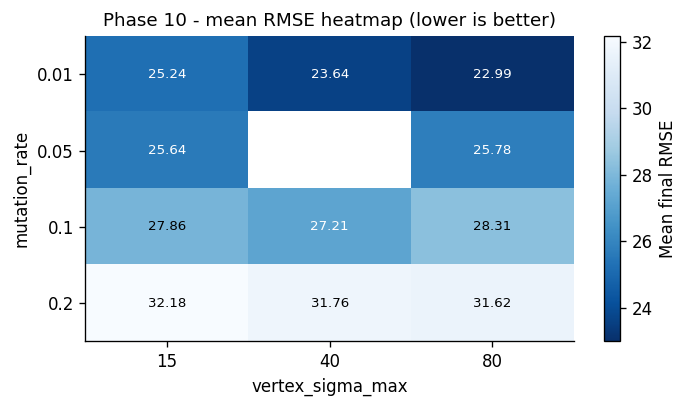

In [45]:
# heatmap of mean final RMSE over the rate x sigma grid

rates      = [0.01, 0.05, 0.10, 0.20]
sigma_vals = [15, 40, 80]

grid = np.full((len(rates), len(sigma_vals)), np.nan)

for i, rate in enumerate(rates):
    for j, sigma in enumerate(sigma_vals):
        name = f"p10_rate_{str(rate).replace('.','')}_sigmax_{sigma}"
        key  = next(((ph, n) for (ph, n) in grouped if ph == 10 and n == name), None)
        if key:
            grid[i, j] = np.mean(grouped[key])

fig, ax = plt.subplots(figsize=(6, 3.5))
im = ax.imshow(grid, aspect="auto", cmap="Blues_r")
plt.colorbar(im, ax=ax, label="Mean final RMSE")
ax.set_xticks(range(len(sigma_vals)))
ax.set_xticklabels(sigma_vals)
ax.set_yticks(range(len(rates)))
ax.set_yticklabels(rates)
ax.set_xlabel("vertex_sigma_max")
ax.set_ylabel("mutation_rate")
ax.set_title("Phase 10 - mean RMSE heatmap (lower is better)", fontsize=11)
for i in range(len(rates)):
    for j in range(len(sigma_vals)):
        if not np.isnan(grid[i, j]):
            ax.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=8, color="white" if grid[i, j] < np.nanmean(grid) else "black")
plt.tight_layout()
plt.show()

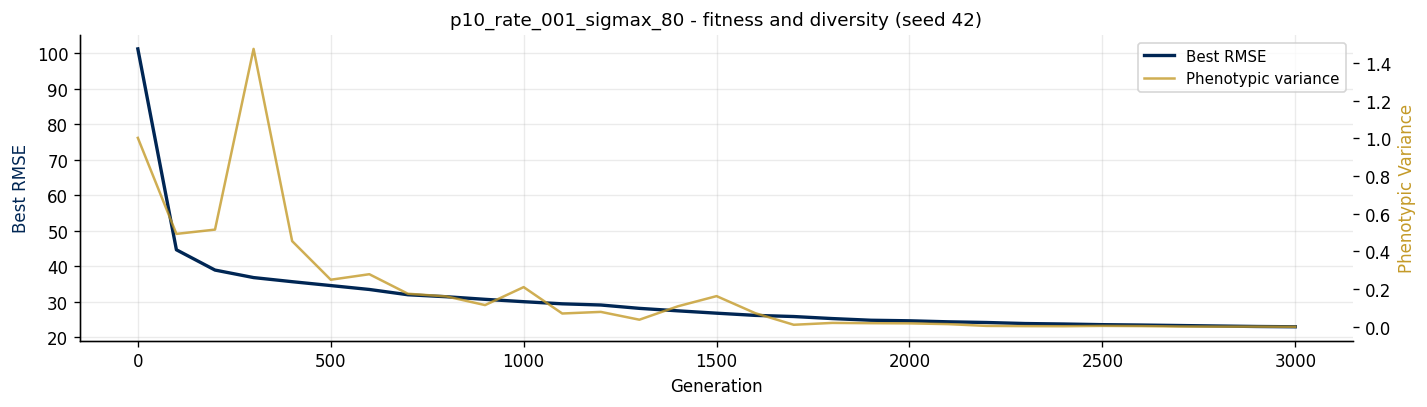

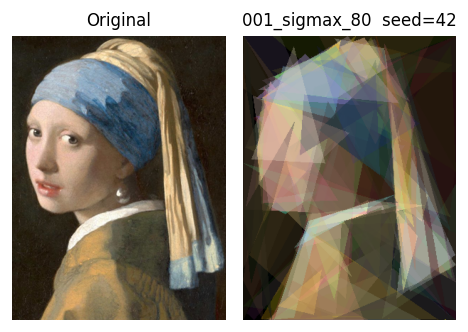

In [46]:
# best config from heatmap: rate=0.01, sigma=80 (lowest mean RMSE)
BEST_P10 = "p10_rate_001_sigmax_80"

plot_diversity(BEST_P10, seed=42, title=f"{BEST_P10} - fitness and diversity (seed 42)")
plot_final_image(BEST_P10, seed=42, figsize=(4, 3))

The heatmap reveals a clear and consistent pattern across the grid. The dominant
factor is `mutation_rate`: lower rates outperform higher ones regardless of
`vertex_sigma_max`. `rate=0.01` occupies the entire top row with the three best
results, while `rate=0.2` occupies the entire bottom row with the three worst —
a gap of ~9 RMSE points between the extremes of the grid.

Within `rate=0.01`, larger sigma performs better: `sigma_max=80` (22.99) >
`sigma_max=40` (23.64) > `sigma_max=15` (25.24). This makes intuitive sense —
at a low mutation rate only ~1 triangle per individual is perturbed per generation
on average, so a large sigma is needed to maintain sufficient perturbation
magnitude and avoid premature convergence. At higher rates the sigma dimension
matters less and eventually becomes detrimental, as seen with `rate=0.1` where
the ranking inverts slightly.

At `rate=0.2`, all sigma values collapse to similar poor performance (~31-32
RMSE): mutating 20 triangles per generation on average overwhelms selection,
effectively randomising the population each generation regardless of step size.

`rate=0.01`, `sigma_max=80` is carried forward as the best configuration.

### 8.2.6. Phase 11 - Population Size Sweep

Tests `N in {100, 150}` with the best configuration from Phase 10 (`tournament_k10`, `blend`, `gaussian_decay`, 3 elites, `quadrant` init, `mutation_rate=0.01`, `vertex_sigma_max=80`). 3 seeds x 3 000 generations.

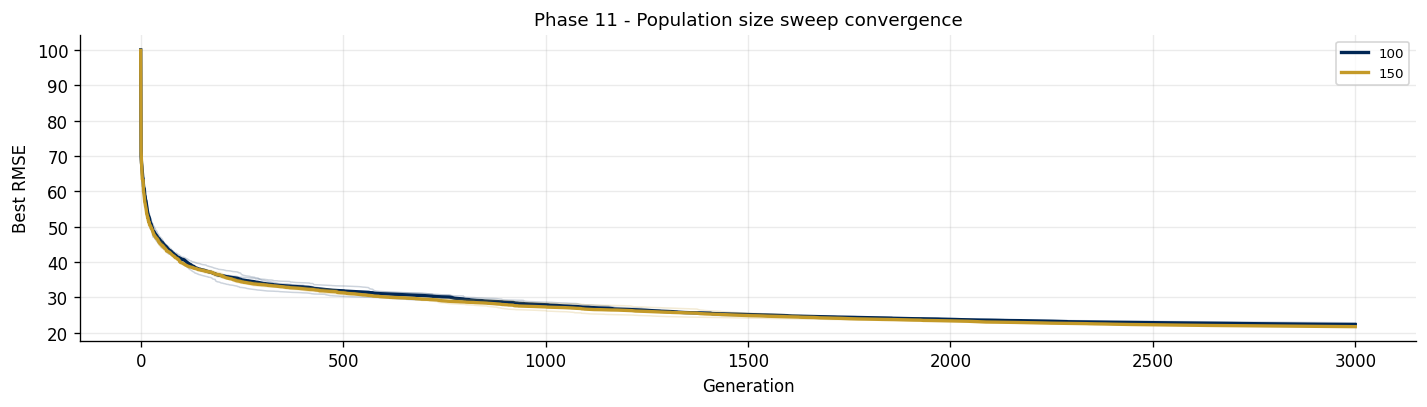

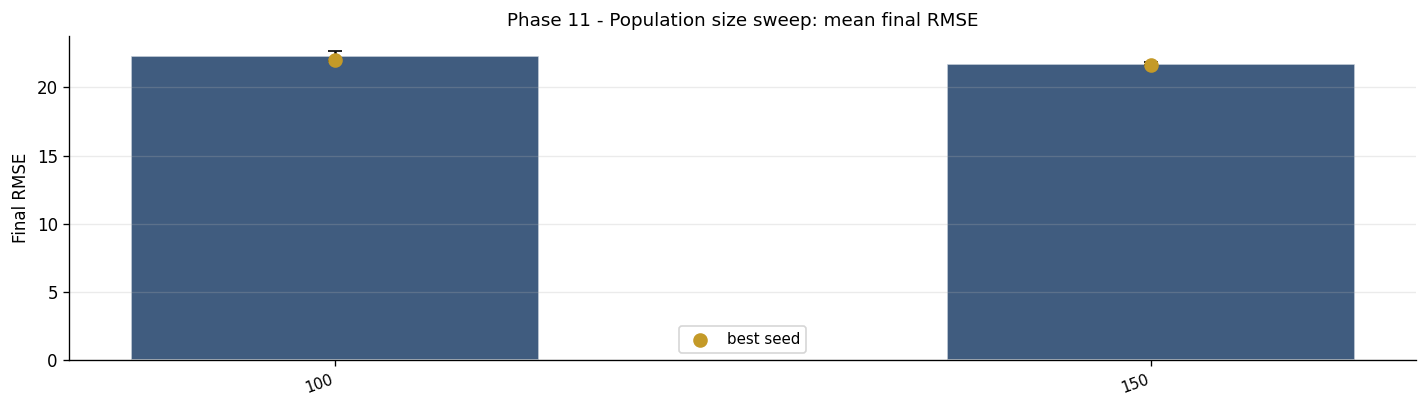


Config                                  Mean      Std     Best
--------------------------------------------------------------
150                                  21.7293   0.0922  21.6358
100                                  22.2815   0.3394  22.0305


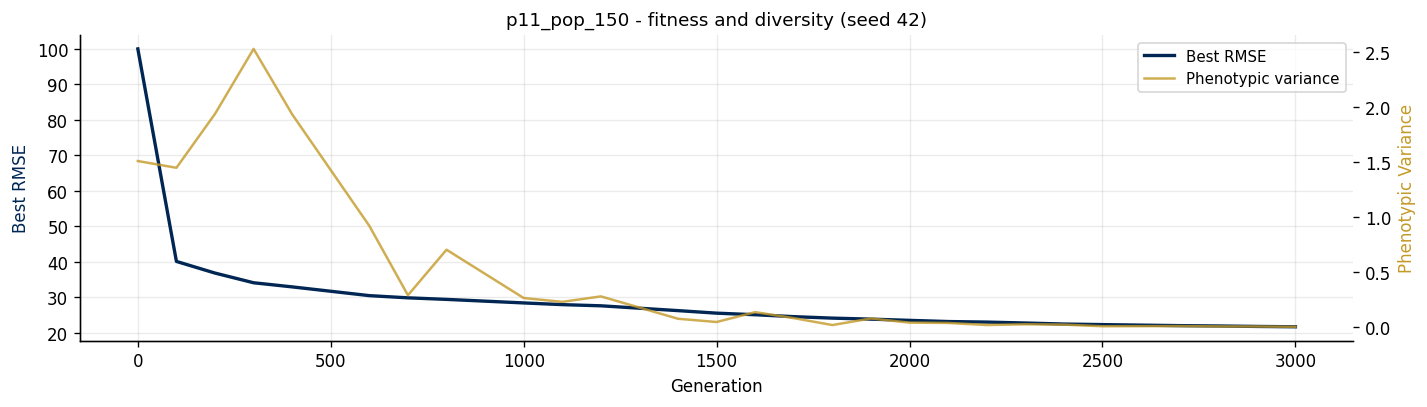

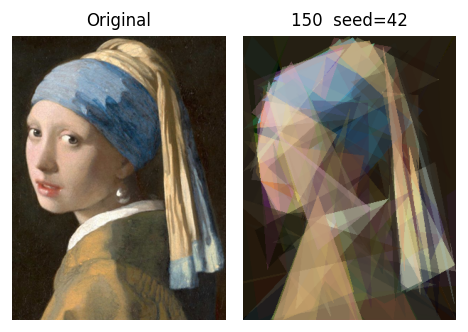

In [59]:
plot_convergence(11, "Phase 11 - Population size sweep convergence")
plot_bar_summary(11, "Phase 11 - Population size sweep: mean final RMSE")
BEST_P11 = "p11_pop_150"

plot_diversity(BEST_P11, seed=42, title=f"{BEST_P11} - fitness and diversity (seed 42)")
plot_final_image(BEST_P11, seed=42, figsize=(4, 3))

Both population sizes converge to similar final RMSE values, with `pop=150` (mean=21.73, std=0.09) outperforming `pop=100` (mean=22.28, std=0.34) by ~0.55 RMSE points. The convergence curves are nearly indistinguishable until generation ~1 500, after which `pop=150` pulls slightly ahead. More notably, `pop=150` achieves considerably lower variance across seeds (std=0.09 vs 0.34), indicating more reliable convergence — a larger gene pool sustains diversity longer and reduces sensitivity to initialisation.

The diversity plot for `pop=150` shows phenotypic variance remaining active through generation ~1 500 with two bursts of diversity recovery around generations 300 and 800, before collapsing near generation 2 000. This extended diversity window compared to earlier phases (where collapse happened before generation 500) is consistent with the larger population providing more varied recombination material. `pop=150` is carried forward to the final runs.

### 8.2.7. Phase 12 - Population Size Sweep

Phase 12 runs the best configuration found across all phases to a 20 000-generation budget. Two population sizes are tested — 150 (carried from Phase 11) and 300 — to assess whether a further increase in population size yields additional gains at the extended budget. Due to the high computational cost, each configuration is run with a single seed only. Both runs use early stopping and stopped before the 20 000 generation ceiling.

> Note: The configuration with population size set to 300 was the best solution and will be analysed in section 10.

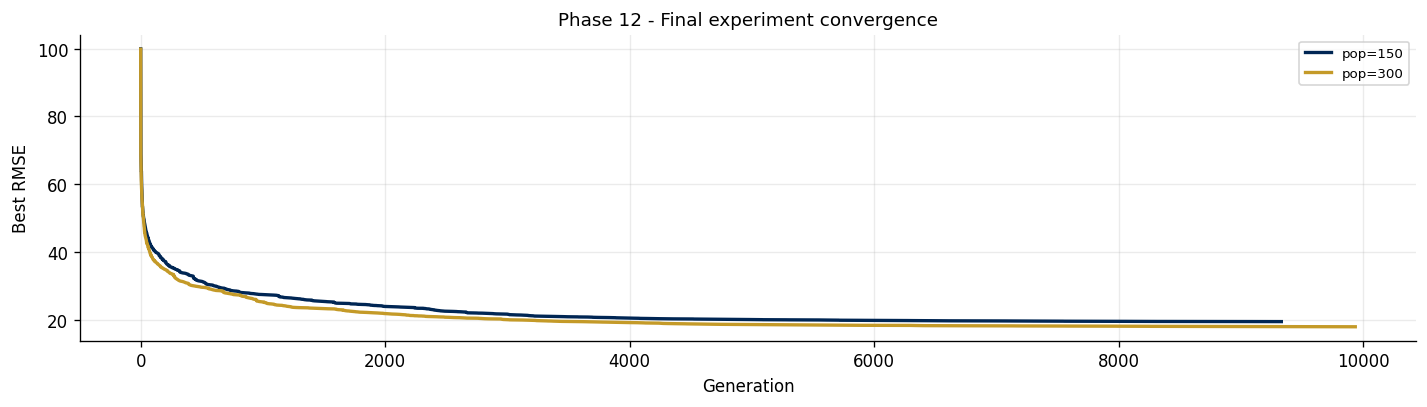

In [50]:
plot_convergence(
    12,
    "Phase 12 - Final experiment convergence",
    label_map={
        "p12_final":     "pop=150",
        "p12_final_300": "pop=300",
    }
)

In [60]:
P12_LABELS = {
    "p12_final":     "pop=150",
    "p12_final_300": "pop=300",
}

print(f"\n{'Config':<12} {'RMSE':>8}")
print("-" * 22)
for name, label in P12_LABELS.items():
    fits = grouped.get((12, name), [])
    if fits:
        print(f"{label:<12} {np.min(fits):>8.4f}")


Config           RMSE
----------------------
pop=150       19.4542
pop=300       17.9300


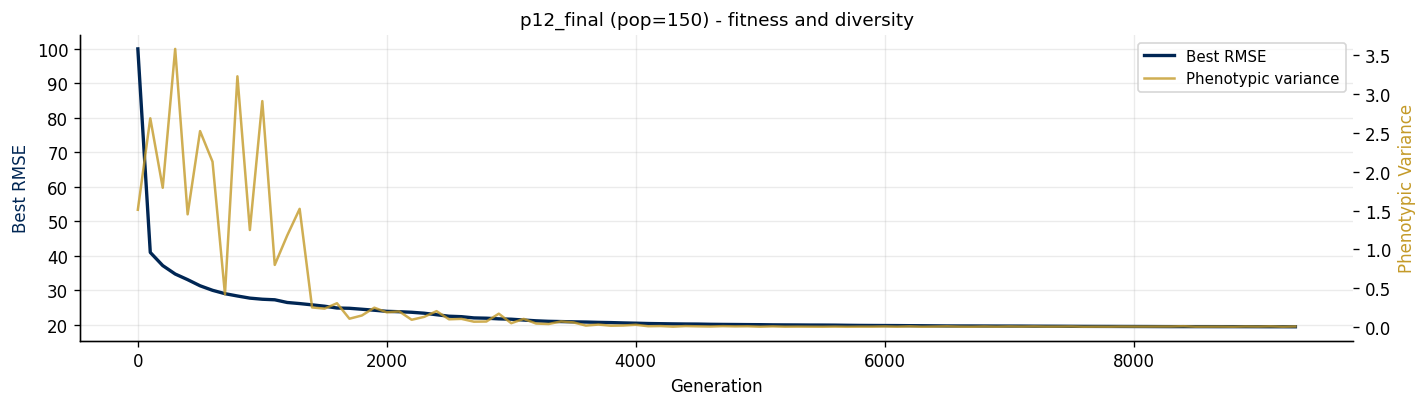

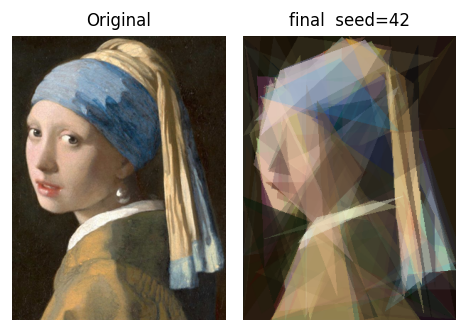

In [51]:
plot_diversity("p12_final", seed=42, title="p12_final (pop=150) - fitness and diversity")
plot_final_image("p12_final", seed=42, figsize=(4, 3))

Both final runs confirm that the extended budget of 20 000 generations yields substantial gains over the 3 000-generation experiments. `pop=300` achieves a final RMSE of 17.93, stopping early at ~9 900 generations, while `pop=150` reaches 19.45 at ~9 300 generations — a gap of ~1.5 RMSE points in favour of the larger population.

The convergence curves show both configs descending continuously through the full run with no clear plateau, suggesting that neither has fully exhausted its potential at early stopping. The diversity plot for `pop=150` is particularly revealing: phenotypic variance oscillates actively through the first ~2 000 generations — much longer than in the 3 000-generation runs from earlier phases — before gradually collapsing after generation 3 000. This extended diversity window is a direct consequence of the `decay_n_generations=5000` setting used in the final config, which calibrates the sigma decay to a 5 000-generation window regardless of the actual run length, keeping perturbation magnitude higher for longer.

`p12_final_300` (pop=300, RMSE=17.93) is the best solution obtained and is used for the final analysis in Section 9.

## 8.3. Statistical Validation

### 8.3.1. Motivation

Genetic Algorithms are stochastic optimisation methods. This means that a single run, no matter how good, is not sufficient evidence that one configuration is genuinely better than another. 

To rigorously validate the improvements achieved through the optimisation process, we apply formal statistical hypothesis testing. The goal is to answer the following question: **is the performance difference between our best model and the baseline statistically significant, or could it be explained by random variation?**

This type of analysis is standard practice in Evolutionary Computation research and follows the methodology described in Vanneschi & Silva (2025), which recommends running multiple independent experiments and comparing distributions of results rather than individual outcomes.

### 8.3.2. Experimental Setup

The statistical comparison was conducted between two configurations:

| | **Best Model** (p12_final) | **Baseline** (p1_baseline) |
|---|---|---|
| Selection | Tournament $(k=10)$ | Tournament $(k=3)$ |
| Crossover | Blend $(\alpha=0.5)$ | Uniform $(swap=0.5)$ |
| Mutation | Gaussian Decay $(\sigma: 80->2)$| Gaussian Fixed $(\sigma=15)$ |
| Elitism | 3 elites | 5 elites |
| Init strategy | Quadrant | Random |

Both configurations were run under identical computational conditions:
- **30 independent runs** per configuration (seeds 0-29)
- **Population size:** 50 individuals
- **Generations:** 1000 per run
- **Fitness function:** RMSE

> **Note**: both the number of generations (reduced from 20 000 to 1000) and the population size (reduced from 150 to 50) were adjusted from the final production run for computational feasibility. The relative performance ordering between configurations is consistent across different parameter settings, as confirmed by the phase sweep results in the previous sections.

The full implementation is available in `statistical_analysis.py`.

### 8.3.3. Statistical Pipeline

Before choosing a test, we verified whether the 30 RMSE values from each configuration followed a normal distribution, using the **Shapiro-Wilk test**. We use this test rather than Kolmogorov-Smirnov test as it is more indicated for small samples ass this one (n=30).  The hypothesis of this test are:

- **$H_0$:** the data follows a normal distribution.
- **$H_1$:** the data does not follow a normal distribution.

A p-value above $ \alpha = 0.05$ means we fail to reject $H_0$, meaning that we have no evidence against normality and can treat the sample as normally distributed.

| | Shapiro-Wilk p-value | Normal? |
|---|---|---|
| Best Model | 0.6819 |  Yes |
| Baseline | 0.8443 |  Yes |

Since both samples are normally distributed, we applied the **Welch t-test**, a variant of Student's t-test that does not assume equal variances between groups. This is the appropriate parametric test for this scenario.

The Welch t-test operates under the following hypotheses:

- **$H_0$:** the two configurations have the same mean RMSE i.e., any observed difference is due to random variation.
- **$H_1$:** the two configurations have different mean RMSE i.e., the difference is systematic and not due to chance.

The test computes a t-statistic based on the difference between the two sample means, scaled by their standard errors. If the resulting p-value falls below the significance threshold $ \alpha = 0.05$ , we reject $H_0$ and conclude that the difference is statistically significant.

### 8.3.4. Results

- **Descriptive Statistics**

| | **Best Model** | **Baseline** |
|---|---|---|
| Mean RMSE | 26.8823 | 32.3077 |
| Std RMSE | 0.5125 | 0.9498 |
| Median RMSE | 26.8946 | 32.2949 |
| n runs | 30 | 30 |

The best model achieves a mean RMSE of **26.88**, compared to **32.31** for the baseline, representing a reduction of approximately 16.8%. Furthermore, the best model is considerably more consistent, with a standard deviation roughly half that of the baseline, indicating more reliable convergence across independent runs.

- **Hypothesis Testing**

| Test | Statistic | p-value | Significant? | Effect size |
|---|---|---|---|---|
| Welch t-test | t = −27.53 | p < 0.001 |  Yes (***) | Cohen's d = 7.11 |

The Welch t-test confirms that the difference is **highly statistically
significant** ($p \approx 0$), well below the $ \alpha = 0.05$ threshold). The effect size of Cohen's d = 7.11 is extraordinarily large (values above 0.8 are already considered "large" in the literature). This means the two distributions are almost entirely non-overlapping, as clearly visible in the boxplot below.

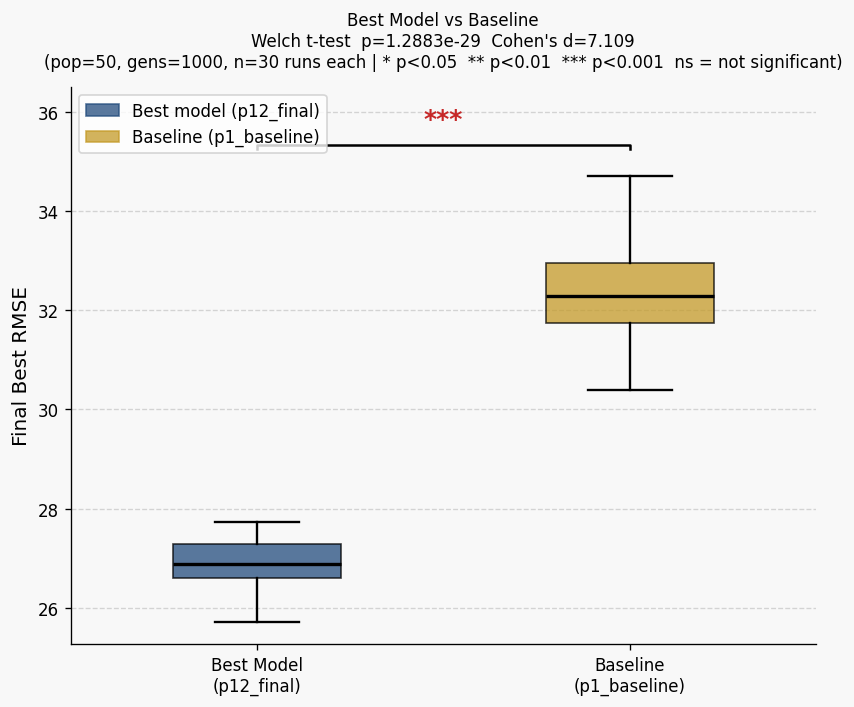

In [ ]:
# Load data from JSON
with open("../src/stat_analysis_outputs/comparison_raw_rmse.json", "r") as f:
    data_raw = json.load(f)

best_model = data_raw["best_model"]
baseline   = data_raw["baseline"]

# Statistical test
_, p_best     = stats.shapiro(best_model)
_, p_baseline = stats.shapiro(baseline)
_, p_value    = stats.ttest_ind(best_model, baseline, equal_var=False)
n1, n2        = len(best_model), len(baseline)
u_stat, _     = stats.mannwhitneyu(best_model, baseline, alternative="two-sided")
cohens_d      = (np.mean(baseline) - np.mean(best_model)) / \
                np.sqrt((np.std(best_model, ddof=1)**2 + np.std(baseline, ddof=1)**2) / 2)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#f8f8f8")
ax.set_facecolor("#f8f8f8")

data   = [best_model, baseline]
labels = ["Best Model\n(p12_final)", "Baseline\n(p1_baseline)"]
colors = ["#234c7d", "#C49A28"]

bp = ax.boxplot(
    data, tick_labels=labels, patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker="o", markersize=5, alpha=0.5),
    widths=0.45,
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# significance bracket
ymax    = max(max(data[0]), max(data[1]))
ymin    = min(min(data[0]), min(data[1]))
y_range = ymax - ymin
y_bar   = ymax + y_range * 0.07
y_text  = y_bar + y_range * 0.03

ax.plot([1, 1, 2, 2], [y_bar - y_range*0.01, y_bar, y_bar, y_bar - y_range*0.01],
        lw=1.5, color="black")
ax.text(1.5, y_text, "***", ha="center", va="bottom",
        fontsize=15, color="#c62828", fontweight="bold")

ax.set_ylim(ymin - y_range * 0.05, y_text + y_range * 0.1)
ax.set_ylabel("Final Best RMSE", fontsize=12)
ax.set_title(
    "Best Model vs Baseline\n"
    f"Welch t-test  p={p_value:.4e}  Cohen's d={cohens_d:.3f}\n"
    f"(pop=50, gens=1000, n={n1} runs each"
    f" | * p<0.05  ** p<0.01  *** p<0.001  ns = not significant)",
    fontsize=10, pad=12,
)
ax.grid(axis="y", linestyle="--", alpha=0.5)

best_patch = mpatches.Patch(color="#234c7d",  alpha=0.75, label="Best model (p12_final)")
base_patch = mpatches.Patch(color="#C49A28", alpha=0.75, label="Baseline (p1_baseline)")
ax.legend(handles=[best_patch, base_patch], loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

> The bracket and \*\*\* annotation indicate a statistically significant difference at p < 0.001 (Welch t-test).

The statistical analysis provides strong evidence that the optimisation process led to a genuine and substantial improvement over the baseline. The best model is not only better on average, but also significantly more consistent across independent runs. The result is statistically significant at p < 0.001 with a very large effect size (Cohen's d = 7.11), confirming that the observed performance gain cannot be attributed to random variation.

# 9. Final Results

### 9.1 Best Reconstruction — Side by Side

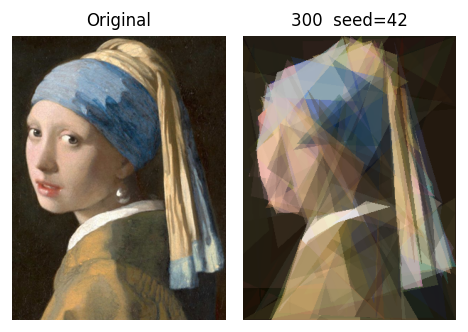

In [32]:
plot_final_image("p12_final_300", seed=42, figsize=(4, 3))

The best result achieved across the entire experiment was obtained with configuration `p12_final_300`: `TournamentSelection` ($k=10$), `BlendCrossover`, `GaussianMutation` with sigma decay, 3 elites, population of 300, and a budget of 20 000 generations. The run completed in approximately 8.8 hours and terminated early at generation **9 937**, meaning the diversity-aware early stopping criterion was met before exhausting the generation budget.

The final best RMSE achieved was **17.93**, representing a **39.6% improvement** over the baseline (29.69). As expected, scaling both population size and the number of generations beyond the values used in earlier phases produced a meaningful improvement from 21.73 (Phase 11, pop=150) to 17.93. This is consistent with the known properties of evolutionary algorithms: a larger population maintains greater genetic diversity throughout the run, reducing the probability of premature convergence and providing more candidate solutions for selection at each generation; while more generations allow the sigma decay schedule to operate over a longer refinement horizon, enabling finer and finer adjustments to triangle geometry and colour before the mutation noise becomes negligibly small.

Looking at the reconstruction, the GA correctly captures the broad structure of the painting: the dark background, the general silhouette, the blue headscarf, and the warm tones of the clothing. Fine detail such as facial features, the pearl earring and the soft skin gradients remain difficult to approximate with only 100 triangles, which is expected given the representational constraints of the problem. Nonetheless, some of these details are still perceptible in the reconstruction: the face region shows a clear lighter area in the correct position, the division between the neck and the face is suggested by a small "line" of triangles and the contrast between the headscarf and the background is well preserved.

### 9.2 Convergence of Best Run

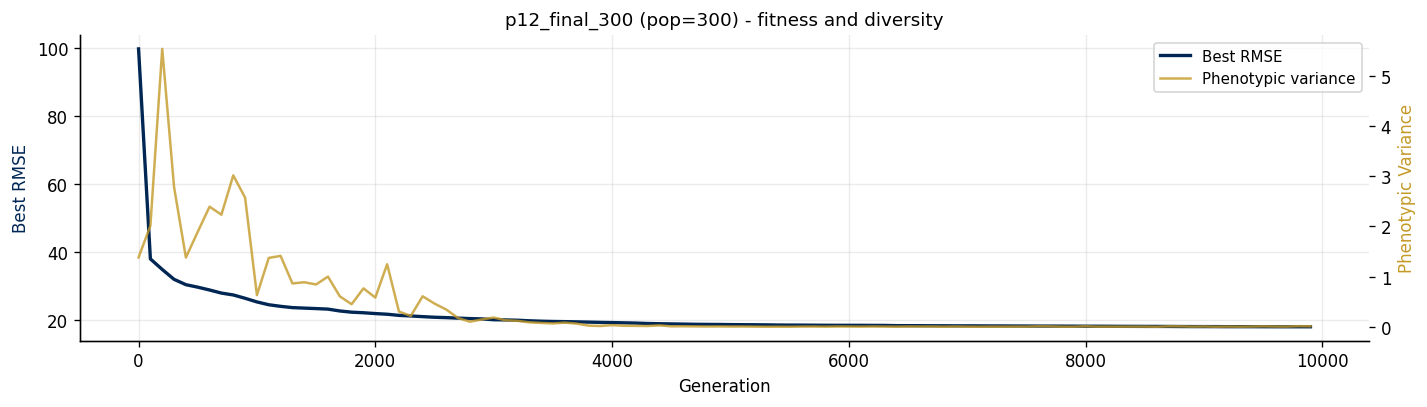

In [33]:
plot_diversity("p12_final_300", seed=42, title="p12_final_300 (pop=300) - fitness and diversity")

The convergence curve reveals several important properties of the final run:

- **Rapid early improvement:** RMSE drops sharply from ~100 to ~35 within the first 500 generations. This reflects the coarse phase of evolution, meaning that large triangles covering broad colour regions are placed quickly.

- **Slow refinement phase:** from generation 500 onwards, improvement becomes gradual and roughly linear on a log scale. This is the fine-grained phase where the sigma decay schedule plays a critical role - as $\sigma$ anneals from 40 to 2, mutations become progressively smaller and more targeted, allowing the GA to refine triangle positions and colours without disrupting already-good solutions.

- **Sigma decay calibration for longer runs:** for this configuration, the `decay_n_generations` parameter was set independently of the total generation budget: rather than decaying $\sigma$ proportionally over the full 20 000 generations, the decay window was fixed to 5 000 generations. The motivation is straightforward: if $\sigma$ decayed over 20 000 generations, it would reach near-zero values extremely early in relative terms, producing almost no mutation for the majority of the run. This would cause the population to stagnate prematurely and trigger early stopping long before the algorithm had meaningfully refined the solution. By decoupling the decay window from the generation budget, $\sigma$ reaches its minimum at generation 5 000, transitioning the algorithm from exploration to exploitation at the right moment, while the remaining generations continue to refine the solution at low but non-negligible noise levels. This is reflected in the smooth, sustained improvement visible in the convergence curve up to approximately generation 5 000, after which the curve flattens as the sigma decay schedule has completed and mutations become very small.

- **Diversity collapse and early stopping:** the phenotypic variance (gold curve) spikes sharply at generation 0 - when the population is fully random and fitness values vary widely - then drops rapidly as the GA converges toward better solutions. Notably, between generations 500 and 2 500, the variance does not collapse monotonically: it exhibits several secondary peaks and partial recoveries, suggesting that the algorithm went through multiple cycles of temporary re-diversification before settling. This is consistent with the sigma decay schedule still operating at moderate values during this window - mutations are large enough to occasionally push individuals into new fitness regions. After generation ~2 500, variance stabilises definitively near zero, indicating that all individuals have converged to a similar fitness region and further improvement can only come from very fine-grained refinement. The diversity-aware early stopping correctly identified this collapse and, combined with fitness stagnation, terminated the run at generation 9 937.

- **Convergence ceiling:** the curve is still very slowly decreasing at termination, suggesting the algorithm had not fully converged. Given the representational limit of 100 triangles, it is likely that the remaining gap between the current RMSE and the theoretical minimum is partly attributable to the expressiveness of the representation itself rather than to insufficient optimisation.